In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/Northeastern_University/Take-home/'

Mounted at /content/drive


In [2]:
!pip -q install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 10.3 MB/s eta 0:00:00


In [5]:
import os
import re
import json


import numpy as np
import pandas as pd
from pandas.api.types import is_numeric_dtype


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import StratifiedKFold, KFold, train_test_split
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_score,
                          recall_score, confusion_matrix)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


from lightgbm import LGBMClassifier, early_stopping, log_evaluation


import xgboost as xgb
from xgboost.callback import EarlyStopping


import optuna

## EDA

In [3]:
def analyze_missing_values(df):
  """
  Summarizes missing values per column in a DataFrame.

  Computes missing count, missing percentage, and data type for
  columns that contain at least one missing value.

  Returns:
      pd.DataFrame: Summary of missing values by column.
  """
  # Count missing values per column
  missing_counts = df.isnull().sum()

  # Keep only columns with at least one missing value
  missing_counts = missing_counts[missing_counts > 0]

  # Percentage of missing values
  missing_percentages = (missing_counts / len(df)) * 100

  # Column data types
  dtypes = df.dtypes.loc[missing_counts.index]

  # Build summary DataFrame
  missing_df = pd.DataFrame({"column": missing_counts.index,
                            "dtype": dtypes.values,
                            "missing_count": missing_counts.values,
                            "missing_pct": missing_percentages.values.round(2),
                          })

  # Sort by missing count
  missing_df = missing_df.sort_values(by="missing_count", ascending=False
                                    ).reset_index(drop=True)

  return missing_df

### 1. Application Data (train, test)

In [ ]:
app_train = pd.read_csv(os.path.join(base_path, 'data/application_train.csv'))
print('Training data shape: ', app_train.shape)
app_train.head()

Training data shape:  (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
app_train['SK_ID_CURR'].nunique()

307511

In [ ]:
app_test = pd.read_csv(os.path.join(base_path, 'data/application_test.csv'))
print('Testing data shape: ', app_test.shape)
app_test.head()

Testing data shape:  (48744, 121)


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


#### 1.1 Check missing values

In [ ]:
analyze_missing_values(app_train)

,column,dtype,missing_count,missing_pct
0,COMMONAREA_MEDI,float64,214865,69.87
1,COMMONAREA_MODE,float64,214865,69.87
2,COMMONAREA_AVG,float64,214865,69.87
3,NONLIVINGAPARTMENTS_MODE,float64,213514,69.43
4,NONLIVINGAPARTMENTS_MEDI,float64,213514,69.43
...,...,...,...,...
62,EXT_SOURCE_2,float64,660,0.21
63,AMT_GOODS_PRICE,float64,278,0.09
64,AMT_ANNUITY,float64,12,0.00
65,CNT_FAM_MEMBERS,float64,2,0.00


In [ ]:
analyze_missing_values(app_test)

,column,dtype,missing_count,missing_pct
0,COMMONAREA_AVG,float64,33495,68.72
1,COMMONAREA_MODE,float64,33495,68.72
2,COMMONAREA_MEDI,float64,33495,68.72
3,NONLIVINGAPARTMENTS_AVG,float64,33347,68.41
4,NONLIVINGAPARTMENTS_MODE,float64,33347,68.41
...,...,...,...,...
59,OBS_30_CNT_SOCIAL_CIRCLE,float64,29,0.06
60,OBS_60_CNT_SOCIAL_CIRCLE,float64,29,0.06
61,DEF_60_CNT_SOCIAL_CIRCLE,float64,29,0.06
62,AMT_ANNUITY,float64,24,0.05


#### 1.2 Column Types

In [ ]:
app_train.dtypes.value_counts()

,count
float64,65
int64,41
object,16


#### 1.3 Categorical Variables

In [ ]:
# Select object columns and count unique values
app_train.select_dtypes('object').apply(pd.Series.nunique, axis=0).sort_values(ascending=False)

,0
ORGANIZATION_TYPE,58
OCCUPATION_TYPE,18
NAME_INCOME_TYPE,8
NAME_TYPE_SUITE,7
WALLSMATERIAL_MODE,7
WEEKDAY_APPR_PROCESS_START,7
NAME_FAMILY_STATUS,6
NAME_HOUSING_TYPE,6
NAME_EDUCATION_TYPE,5
FONDKAPREMONT_MODE,4


`CODE_GENDER`

In [ ]:
app_train['CODE_GENDER'].value_counts()

,count
CODE_GENDER,
F,202448
M,105059
XNA,4


In [ ]:
app_test['CODE_GENDER'].value_counts()

,count
CODE_GENDER,
F,32678
M,16066


`NAME_CONTRACT_TYPE`

In [ ]:
app_train['NAME_CONTRACT_TYPE'].value_counts(normalize=True)

,proportion
NAME_CONTRACT_TYPE,
Cash loans,0.904787
Revolving loans,0.095213


`FLAG_OWN_CAR` and `FLAG_OWN_REALTY`

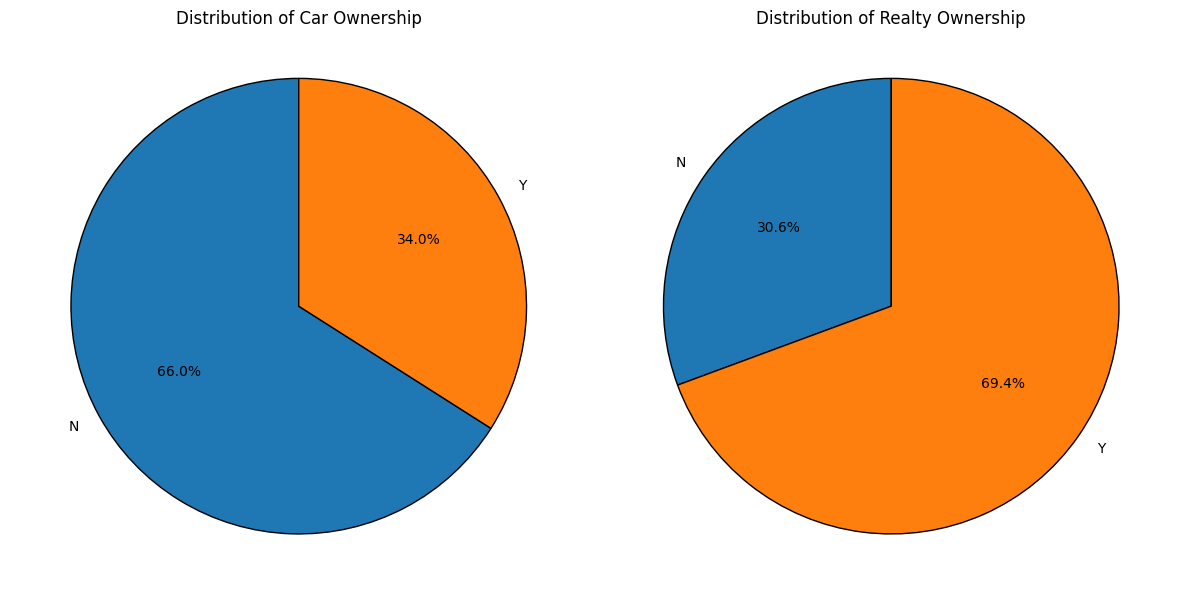

In [ ]:
own_car_counts = app_train['FLAG_OWN_CAR'].value_counts()
own_realty_counts = app_train['FLAG_OWN_REALTY'].value_counts()

# Define consistent colors for 'Y' and 'N'
color_map = {'Y': '#ff7f0e', 'N': '#1f77b4'}

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Pie chart for FLAG_OWN_CAR
cars_labels_sorted = sorted(own_car_counts.index)
cars_colors = [color_map[label] for label in cars_labels_sorted]
axes[0].pie(own_car_counts[cars_labels_sorted], labels=cars_labels_sorted, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'}, colors=cars_colors)
axes[0].set_title('Distribution of Car Ownership')
axes[0].axis('equal')

# Pie chart for FLAG_OWN_REALTY
realty_labels_sorted = sorted(own_realty_counts.index)
realty_colors = [color_map[label] for label in realty_labels_sorted]
axes[1].pie(own_realty_counts[realty_labels_sorted], labels=realty_labels_sorted, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'}, colors=realty_colors)
axes[1].set_title('Distribution of Realty Ownership')
axes[1].axis('equal')

plt.tight_layout()
plt.show()

`NAME_INCOME_TYPE`

In [ ]:
app_train['NAME_INCOME_TYPE'].value_counts(normalize=True)

,proportion
NAME_INCOME_TYPE,
Working,0.516320
Commercial associate,0.232892
Pensioner,0.180033
State servant,0.070576
Unemployed,0.000072
Student,0.000059
Businessman,0.000033
Maternity leave,0.000016


`NAME_FAMILY_STATUS`

In [ ]:
app_train['NAME_FAMILY_STATUS'].value_counts()

,count
NAME_FAMILY_STATUS,
Married,196432
Single / not married,45444
Civil marriage,29775
Separated,19770
Widow,16088
Unknown,2


`OCCUPATION_TYPE`

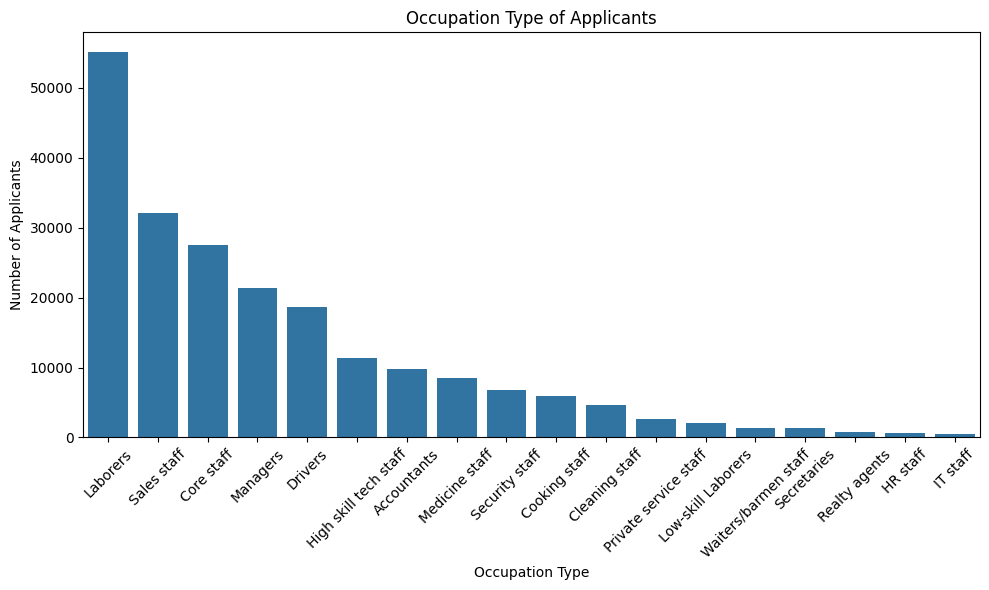

In [ ]:
occupation_counts = app_train['OCCUPATION_TYPE'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=occupation_counts.index, y=occupation_counts.values)
plt.xticks(rotation=45)
plt.title('Occupation Type of Applicants')
plt.xlabel('Occupation Type')
plt.ylabel('Number of Applicants')
plt.tight_layout()
plt.show()

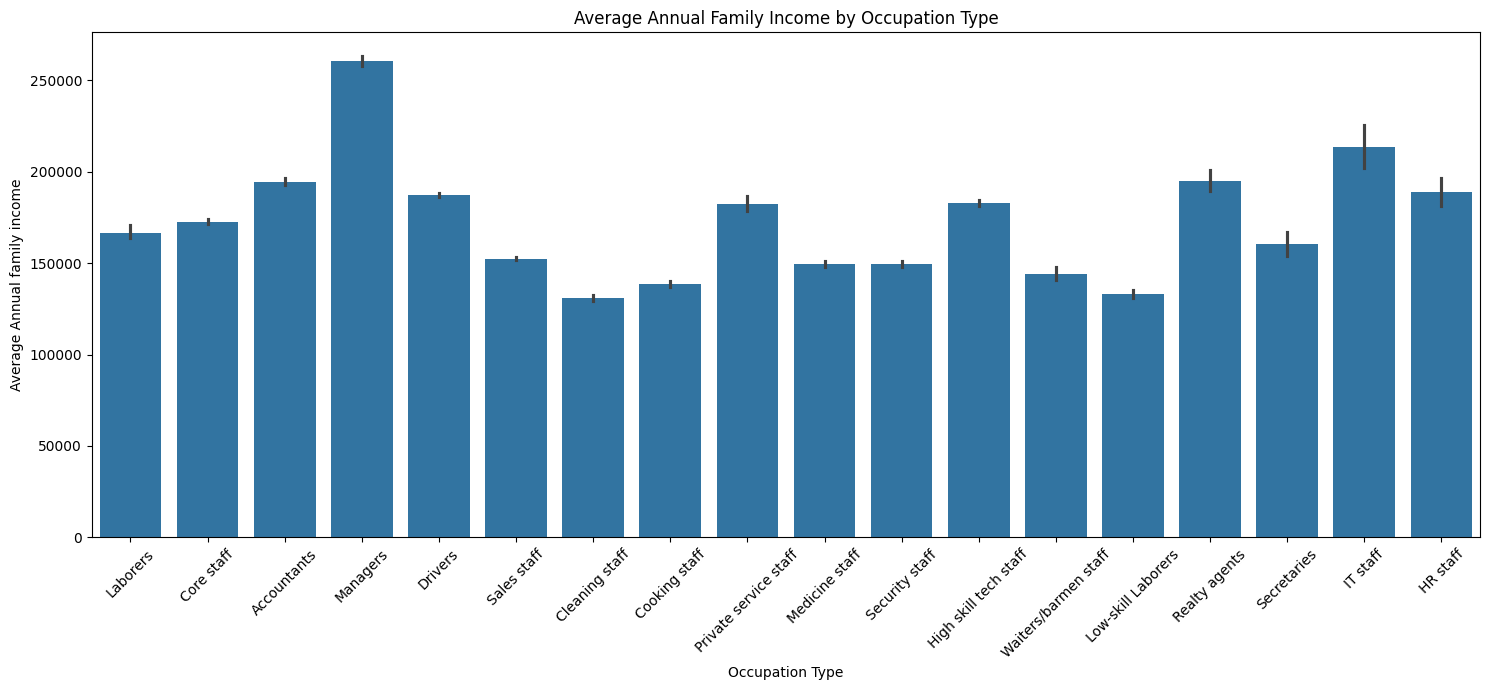

In [ ]:
fig, ax = plt.subplots(figsize=(15,7))
sns.barplot(x='OCCUPATION_TYPE',y='AMT_INCOME_TOTAL',data=app_train)
plt.xticks(rotation=45)
plt.title('Average Annual Family Income by Occupation Type')
plt.xlabel("Occupation Type")
plt.ylabel("Average Annual family income")
plt.tight_layout()
plt.show()

`ORGANIZATION_TYPE`

In [ ]:
app_train['ORGANIZATION_TYPE'].value_counts(normalize=True)

,proportion
ORGANIZATION_TYPE,
Business Entity Type 3,0.221104
XNA,0.180072
Self-employed,0.124913
Other,0.054252
Medicine,0.036399
Business Entity Type 2,0.034317
Government,0.033833
School,0.028919
Trade: type 7,0.025466


`WEEKDAY_APPR_PROCESS_START`

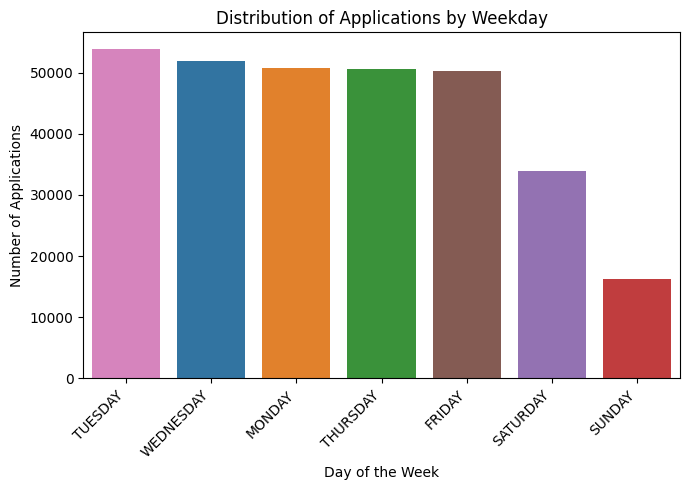

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(data=app_train, x='WEEKDAY_APPR_PROCESS_START', order=app_train['WEEKDAY_APPR_PROCESS_START'].value_counts().index, hue='WEEKDAY_APPR_PROCESS_START',legend=False)
plt.title('Distribution of Applications by Weekday')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Applications')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

`CNT_FAM_MEMBERS`

In [ ]:
app_train['CNT_FAM_MEMBERS'].value_counts() # outliers

,count
CNT_FAM_MEMBERS,
2.0,158357
1.0,67847
3.0,52601
4.0,24697
5.0,3478
6.0,408
7.0,81
8.0,20
9.0,6


`CNT_CHILDREN`

In [ ]:
app_train['CNT_CHILDREN'].value_counts()

,count
CNT_CHILDREN,
0,215371
1,61119
2,26749
3,3717
4,429
5,84
6,21
7,7
14,3


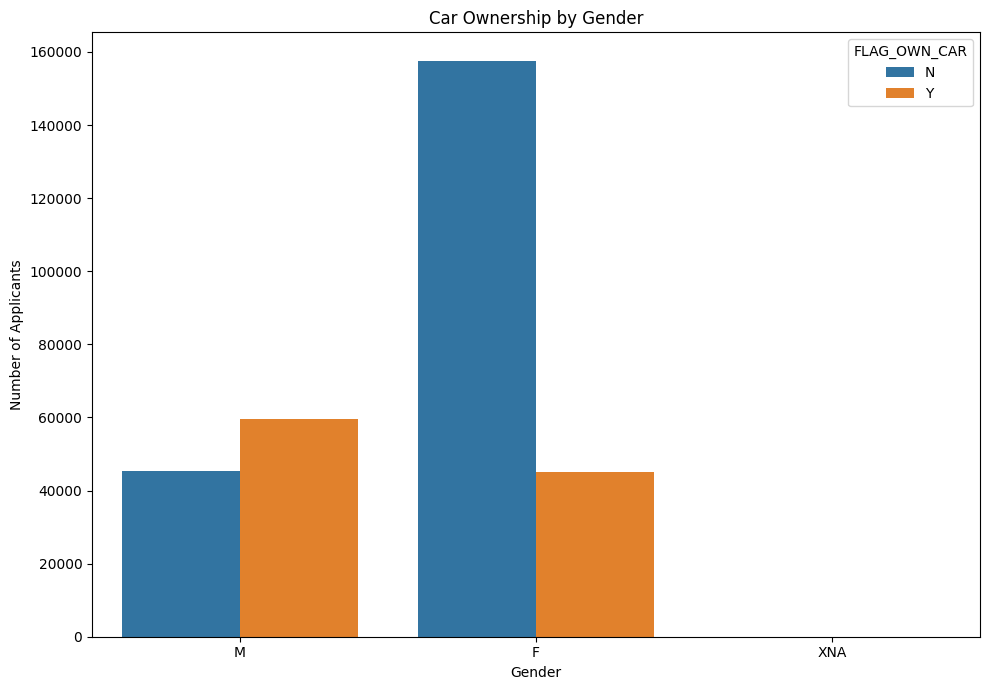

In [ ]:
# Who owns most number of the cars? M or F?
fig, ax = plt.subplots(figsize=(10,7))
sns.countplot(x='CODE_GENDER', hue='FLAG_OWN_CAR', data=app_train)
plt.title('Car Ownership by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Applicants')
plt.tight_layout()
plt.show()

#### 1.4 Target variable

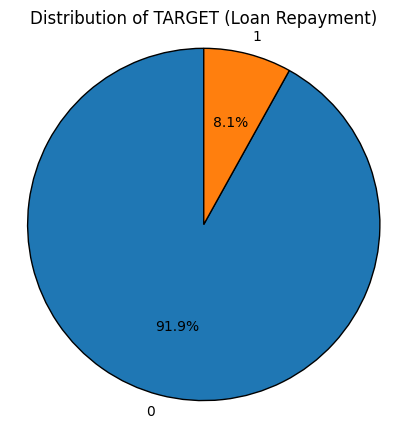

In [ ]:
target_counts = app_train['TARGET'].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title('Distribution of TARGET (Loan Repayment)')
plt.axis('equal')
plt.show()

`TARGET` vs `NAME_INCOME_TYPE`

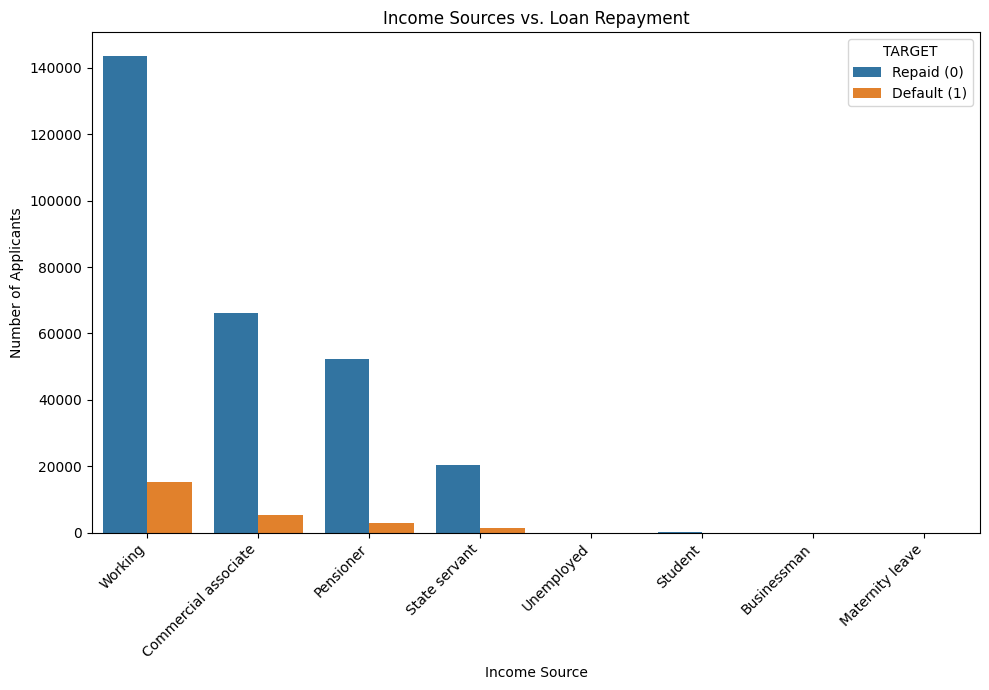

In [ ]:
income_order = app_train['NAME_INCOME_TYPE'].value_counts().index

plt.figure(figsize=(10, 7))
sns.countplot(data=app_train, x='NAME_INCOME_TYPE', hue='TARGET', order=income_order)
plt.title('Income Sources vs. Loan Repayment')
plt.xlabel('Income Source')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=45, ha='right')
plt.legend(title='TARGET', labels=['Repaid (0)', 'Default (1)'])
plt.tight_layout()
plt.show()

`TARGET` vs `NAME_EDUCATION_TYPE`

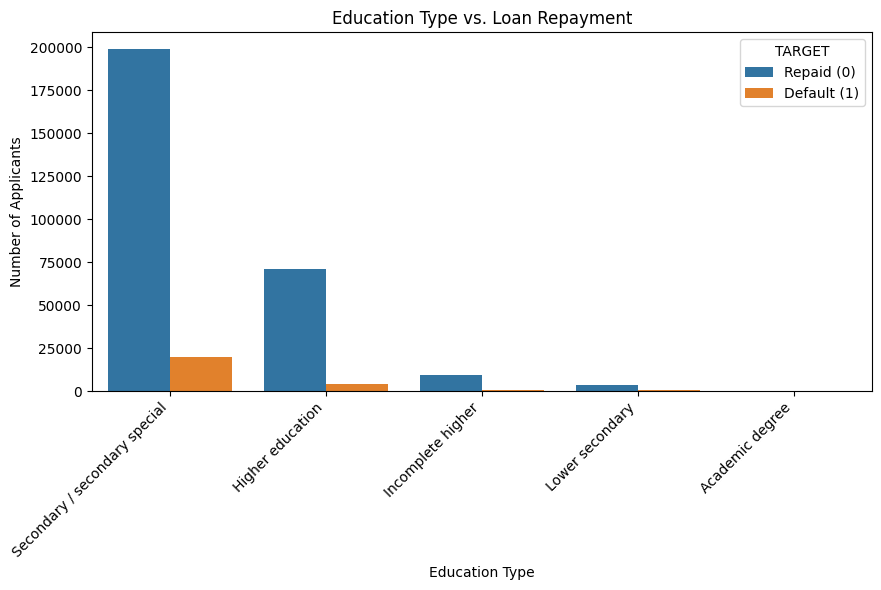

In [ ]:
education_order = app_train['NAME_EDUCATION_TYPE'].value_counts().index

plt.figure(figsize=(9, 6))
sns.countplot(data=app_train, x='NAME_EDUCATION_TYPE', hue='TARGET', order=education_order)
plt.title('Education Type vs. Loan Repayment')
plt.xlabel('Education Type')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=45, ha='right')
plt.legend(title='TARGET', labels=['Repaid (0)', 'Default (1)'])
plt.tight_layout()
plt.show()

`TARGET` vs `REGION_RATING_CLIENT`

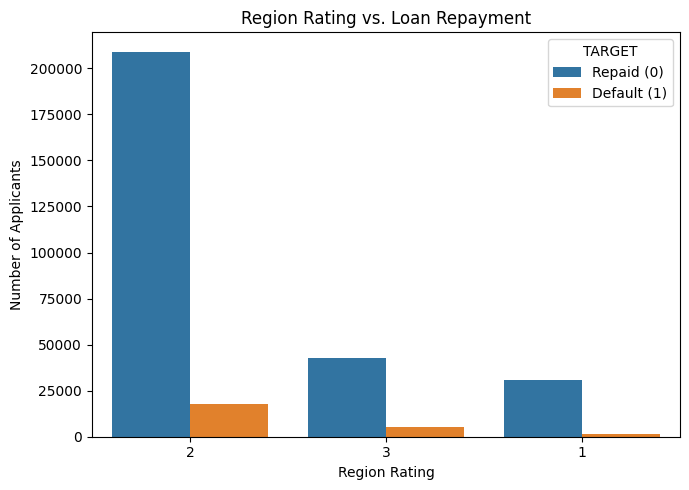

In [ ]:
region_order = app_train['REGION_RATING_CLIENT'].value_counts().index

plt.figure(figsize=(7, 5))
sns.countplot(data=app_train, x='REGION_RATING_CLIENT', hue='TARGET', order=region_order)
plt.title('Region Rating vs. Loan Repayment')
plt.xlabel('Region Rating')
plt.ylabel('Number of Applicants')
plt.legend(title='TARGET', labels=['Repaid (0)', 'Default (1)'])
plt.tight_layout()
plt.show()

`TARGET` vs `NAME_FAMILY_STATUS`

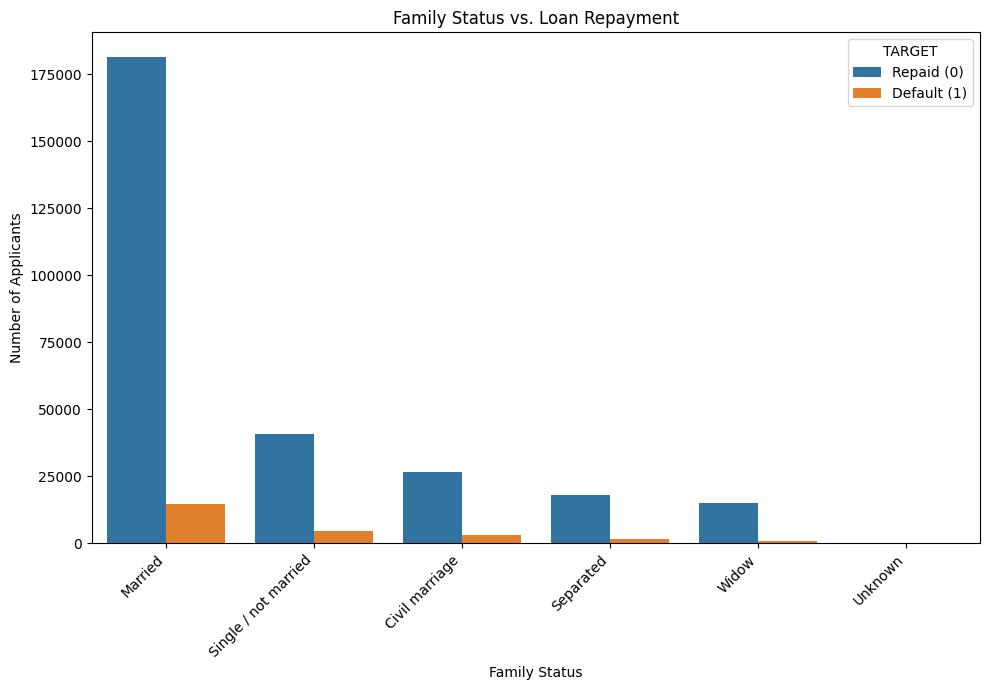

In [ ]:
family_status_order = app_train['NAME_FAMILY_STATUS'].value_counts().index

plt.figure(figsize=(10, 7))
sns.countplot(data=app_train, x='NAME_FAMILY_STATUS', hue='TARGET', order=family_status_order)
plt.title('Family Status vs. Loan Repayment')
plt.xlabel('Family Status')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=45, ha='right')
plt.legend(title='TARGET', labels=['Repaid (0)', 'Default (1)'])
plt.tight_layout()
plt.show()

`TARGET` vs `OCCUPATION_TYPE`

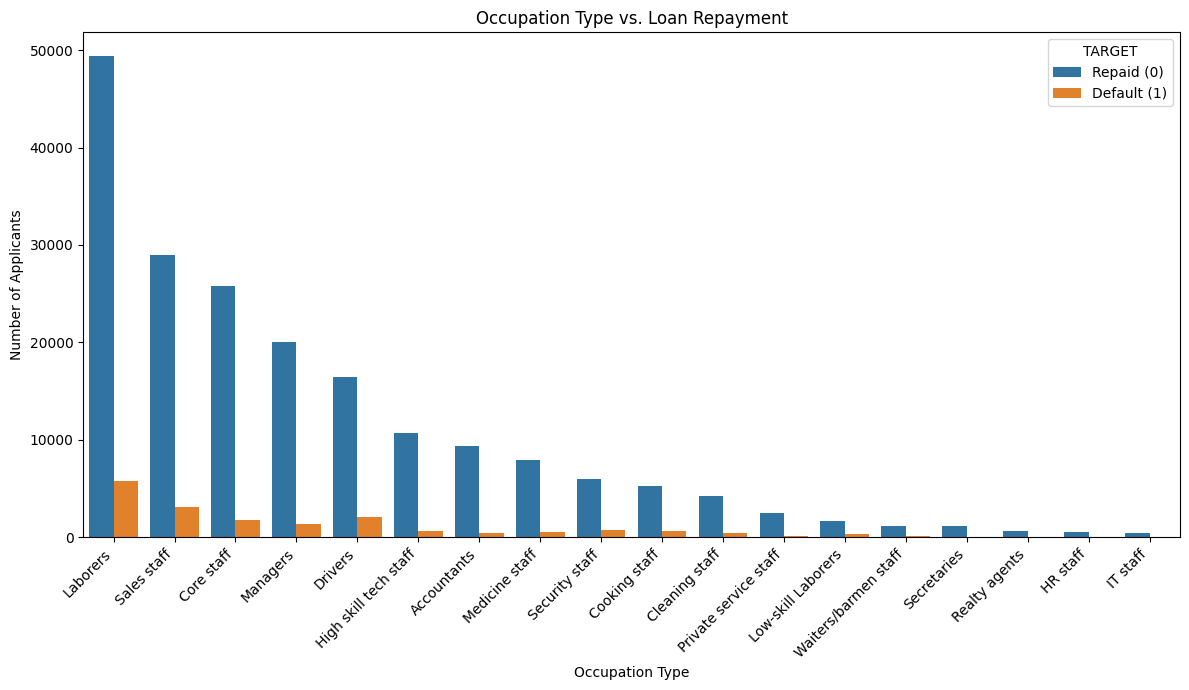

In [ ]:
occupation_order = app_train['OCCUPATION_TYPE'].value_counts().index

plt.figure(figsize=(12, 7))
sns.countplot(data=app_train, x='OCCUPATION_TYPE', hue='TARGET', order=occupation_order)
plt.title('Occupation Type vs. Loan Repayment')
plt.xlabel('Occupation Type')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=45, ha='right')
plt.legend(title='TARGET', labels=['Repaid (0)', 'Default (1)'])
plt.tight_layout()
plt.show()

`TARGET` vs `DAYS_BIRTH`

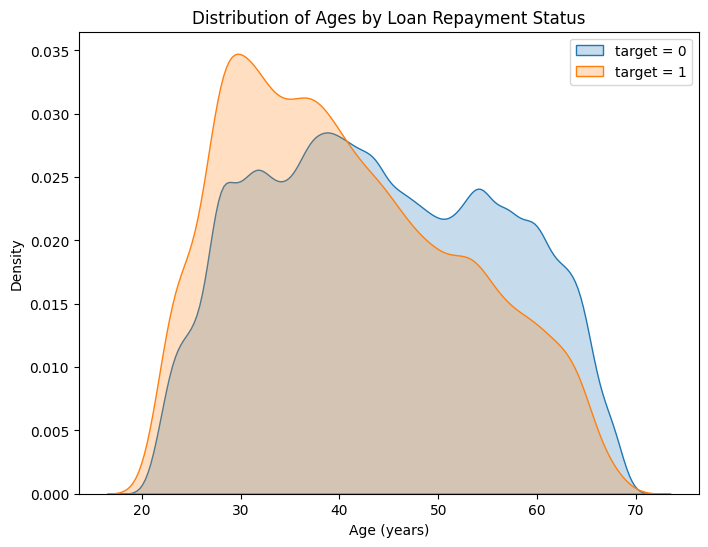

In [ ]:
plt.figure(figsize = (8, 6))

# KDE plot of loans that were repaid on time (TARGET == 0)
sns.kdeplot(app_train.loc[app_train['TARGET'] == 0, 'DAYS_BIRTH'] / -365, label = 'target = 0', fill=True)

# KDE plot of loans which were not repaid on time (TARGET == 1)
sns.kdeplot(app_train.loc[app_train['TARGET'] == 1, 'DAYS_BIRTH'] / -365, label = 'target = 1', fill=True)

plt.xlabel('Age (years)');
plt.ylabel('Density');
plt.title('Distribution of Ages by Loan Repayment Status');
plt.legend()
plt.show()

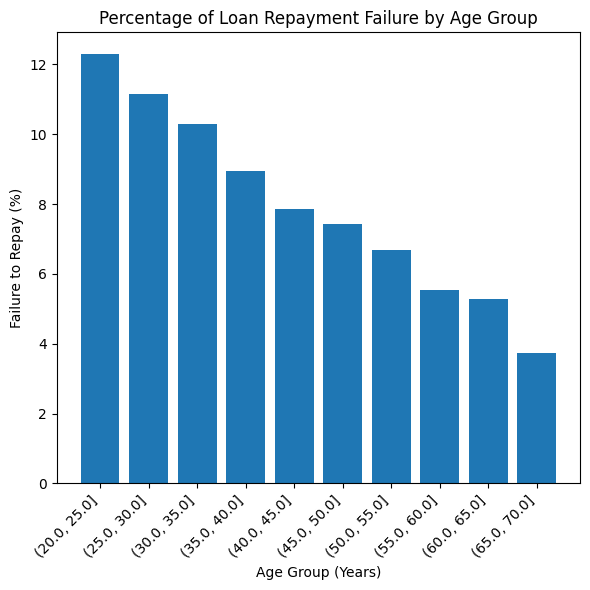

In [ ]:
age_analysis_df = app_train[['TARGET', 'DAYS_BIRTH']].copy()

# Convert DAYS_BIRTH to years (positive values)
age_analysis_df['YEARS_BIRTH'] = age_analysis_df['DAYS_BIRTH'] / -365

# Define age bins (5-year intervals from 20 to 70)
age_analysis_df['AGE_BIN'] = pd.cut(age_analysis_df['YEARS_BIRTH'], bins=np.linspace(20, 70, num=11))

# Calculate the mean TARGET for each age bin
age_group_summary = age_analysis_df.groupby('AGE_BIN', observed=False)['TARGET'].mean().reset_index()

plt.figure(figsize=(6, 6))
plt.bar(age_group_summary['AGE_BIN'].astype(str), 100 * age_group_summary['TARGET'])
plt.xlabel('Age Group (Years)')
plt.ylabel('Failure to Repay (%)')
plt.title('Percentage of Loan Repayment Failure by Age Group')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

`TARGET` vs `EXT_SOURCE_3`, `EXT_SOURCE_2`, `EXT_SOURCE_1`

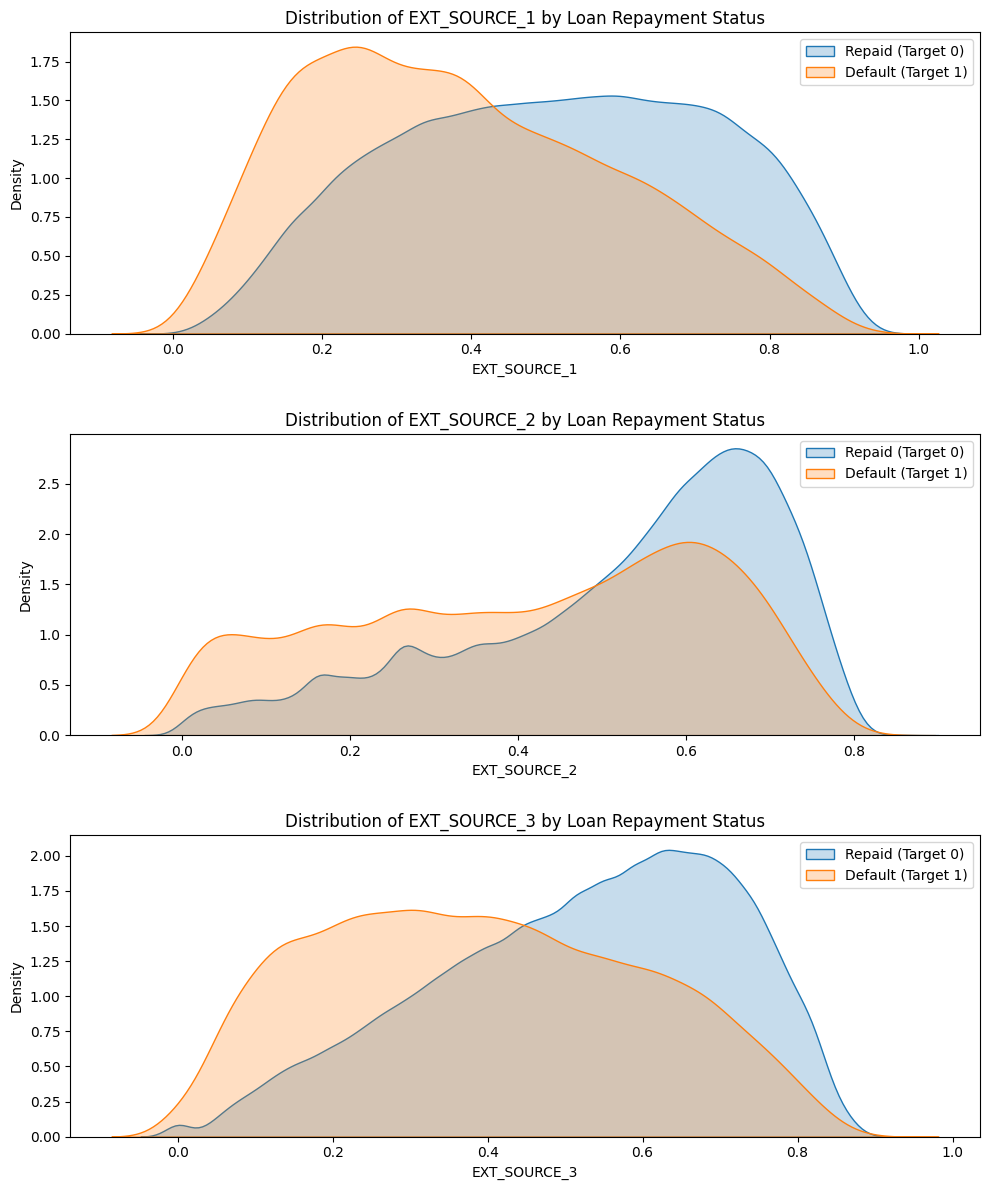

In [ ]:
plt.figure(figsize=(10, 12))

for i, source in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
  plt.subplot(3, 1, i + 1)

  sns.kdeplot(app_train.loc[app_train['TARGET'] == 0, source].dropna(), label = 'Repaid (Target 0)', fill=True)
  sns.kdeplot(app_train.loc[app_train['TARGET'] == 1, source].dropna(), label = 'Default (Target 1)', fill=True)

  plt.title(f'Distribution of {source} by Loan Repayment Status')
  plt.xlabel(source);
  plt.ylabel('Density');
  plt.legend()

plt.tight_layout(h_pad = 2.5)
plt.show()

#### 1.5 Numerical Variables

`AMT_CREDIT`

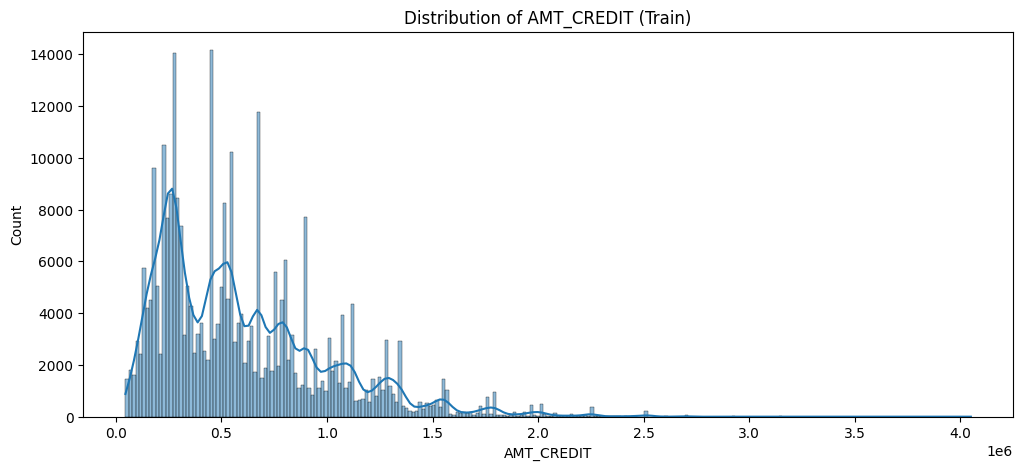

In [ ]:
plt.figure(figsize=(12,5))
plt.title("Distribution of AMT_CREDIT (Train)")
ax = sns.histplot(app_train["AMT_CREDIT"], kde=True)

`AMT_GOODS_PRICE`

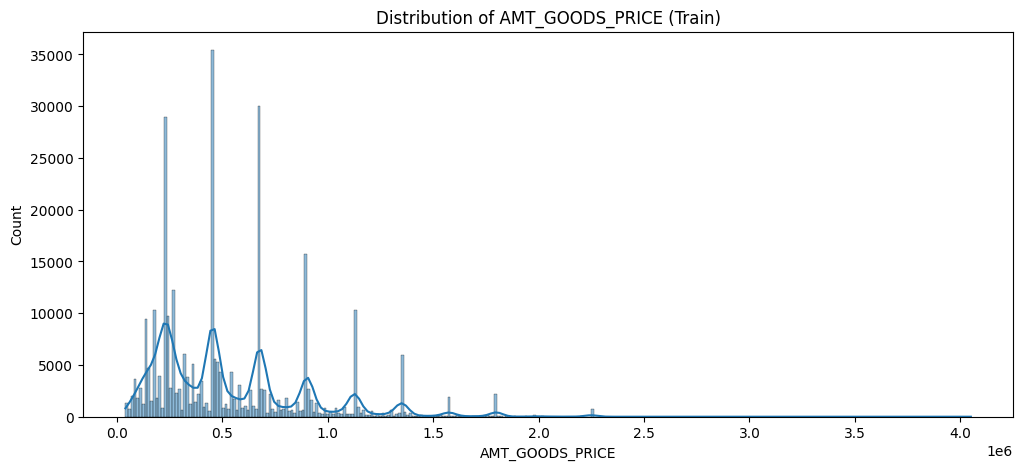

In [ ]:
plt.figure(figsize=(12,5))
plt.title("Distribution of AMT_GOODS_PRICE (Train)")
ax = sns.histplot(app_train["AMT_GOODS_PRICE"], kde=True)

`AMT_ANNUITY`

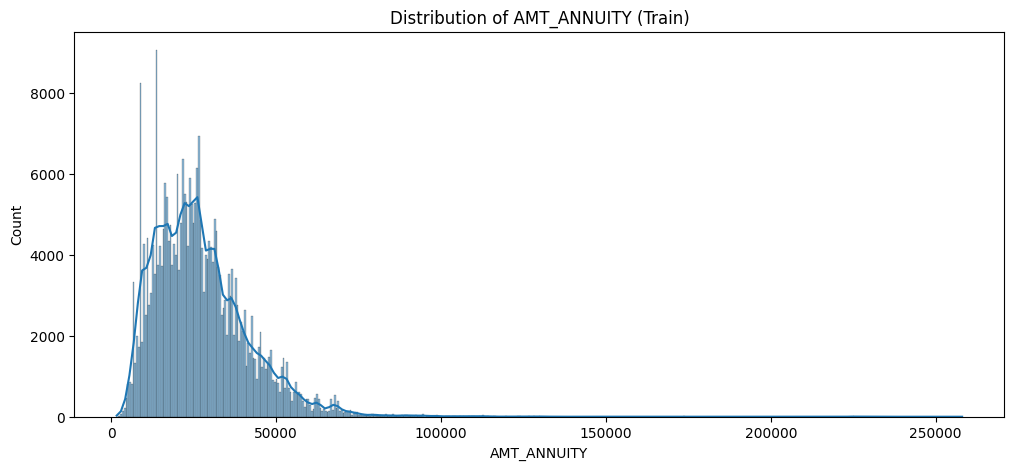

In [ ]:
plt.figure(figsize=(12,5))
plt.title("Distribution of AMT_ANNUITY (Train)")
ax = sns.histplot(app_train["AMT_ANNUITY"], kde=True)

`DAYS_BIRTH`

In [ ]:
app_train[app_train['DAYS_BIRTH']>0] # all negative values

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR


In [ ]:
(app_train['DAYS_BIRTH'] / 365).describe()

,DAYS_BIRTH
count,307511.000000
mean,-43.936973
std,11.956133
min,-69.120548
25%,-53.923288
50%,-43.150685
75%,-34.008219
max,-20.517808


`DAYS_EMPLOYED`

In [ ]:
(app_train['DAYS_EMPLOYED'] / 365).describe() # 1000 years?

,DAYS_EMPLOYED
count,307511.000000
mean,174.835742
std,387.056895
min,-49.073973
25%,-7.561644
50%,-3.323288
75%,-0.791781
max,1000.665753


In [ ]:
app_train['DAYS_EMPLOYED'][app_train['DAYS_EMPLOYED']>0].value_counts()
# if positive all = 365243 days seems to be anomaly --> replace with NaN and flag as anomaly

,count
DAYS_EMPLOYED,
365243,55374


`OWN_CAR_AGE`

In [ ]:
app_train['OWN_CAR_AGE'].describe() # max 91 years

,OWN_CAR_AGE
count,104582.000000
mean,12.061091
std,11.944812
min,0.000000
25%,5.000000
50%,9.000000
75%,15.000000
max,91.000000


In [ ]:
Q1 = app_train["OWN_CAR_AGE"].quantile(0.25)
Q3 = app_train["OWN_CAR_AGE"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = app_train[(app_train["OWN_CAR_AGE"] < lower) | (app_train["OWN_CAR_AGE"] > upper)]

len(outliers), round(len(outliers) / len(app_train) * 100, 4)

(4932, 1.6038)

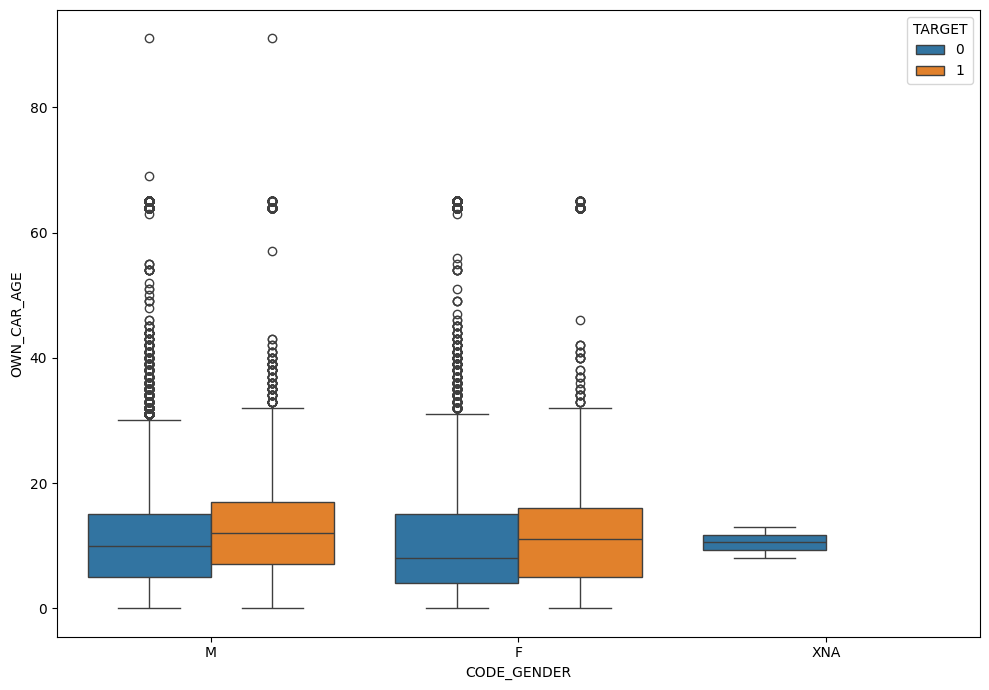

In [ ]:
# How old is the client's car(s)?
fig, ax = plt.subplots(figsize=(10,7))
sns.boxplot(x='CODE_GENDER',y='OWN_CAR_AGE',hue='TARGET',data=app_train)
plt.tight_layout()
plt.show()

#### 1.6 Correlation

In [ ]:
# Keep only numeric cols (TARGET included)
num_df = app_train.select_dtypes(include=[np.number])

# Correlation of numeric features with TARGET
correlations = num_df.corr(numeric_only=True)["TARGET"].drop("TARGET").sort_values()

In [ ]:
print("Most Positive Correlations:\n")
correlations.tail(15)

Most Positive Correlations:



,TARGET
FLAG_WORK_PHONE,0.028524
DEF_60_CNT_SOCIAL_CIRCLE,0.031276
DEF_30_CNT_SOCIAL_CIRCLE,0.032248
LIVE_CITY_NOT_WORK_CITY,0.032518
OWN_CAR_AGE,0.037612
DAYS_REGISTRATION,0.041975
FLAG_DOCUMENT_3,0.044346
REG_CITY_NOT_LIVE_CITY,0.044395
FLAG_EMP_PHONE,0.045982
REG_CITY_NOT_WORK_CITY,0.050994


In [ ]:
print("Most Negative Correlations:")
correlations.head(15)

Most Negative Correlations:


,TARGET
EXT_SOURCE_3,-0.178919
EXT_SOURCE_2,-0.160472
EXT_SOURCE_1,-0.155317
DAYS_EMPLOYED,-0.044932
FLOORSMAX_AVG,-0.044003
FLOORSMAX_MEDI,-0.043768
FLOORSMAX_MODE,-0.043226
AMT_GOODS_PRICE,-0.039645
REGION_POPULATION_RELATIVE,-0.037227
ELEVATORS_AVG,-0.034199


### 2. Bureau Data

*This table consists of all client's previous credit records with financial institutions other than Home Credit Group which were reported by the Credit Bureau.*

In [ ]:
bureau = pd.read_csv(os.path.join(base_path, 'data/bureau.csv'))
print('Bureau data shape: ', bureau.shape)
bureau.head()

Bureau data shape:  (1716428, 17)


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [ ]:
bureau["SK_ID_CURR"].unique().shape[0] # applicant-level

305811

In [ ]:
bureau['SK_ID_BUREAU'].unique().shape[0] # loan-level

1716428

#### 2.1 Checking missing values

In [ ]:
analyze_missing_values(bureau)

,column,dtype,missing_count,missing_pct
0,AMT_ANNUITY,float64,1226791,71.47
1,AMT_CREDIT_MAX_OVERDUE,float64,1124488,65.51
2,DAYS_ENDDATE_FACT,float64,633653,36.92
3,AMT_CREDIT_SUM_LIMIT,float64,591780,34.48
4,AMT_CREDIT_SUM_DEBT,float64,257669,15.01
5,DAYS_CREDIT_ENDDATE,float64,105553,6.15
6,AMT_CREDIT_SUM,float64,13,0.00


#### 2.2 Column Types

In [ ]:
bureau.dtypes.value_counts()

,count
float64,8
int64,6
object,3


#### 2.3 Categorical Variables

In [ ]:
# Select object columns and count unique values using a concise method
bureau.select_dtypes('object').apply(pd.Series.nunique, axis=0).sort_values(ascending=False)

,0
CREDIT_TYPE,15
CREDIT_ACTIVE,4
CREDIT_CURRENCY,4


In [ ]:
bureau['CREDIT_CURRENCY'].value_counts(normalize=True)

,proportion
CREDIT_CURRENCY,
currency 1,0.999180
currency 2,0.000713
currency 3,0.000101
currency 4,0.000006


In [ ]:
bureau["CREDIT_ACTIVE"].value_counts(normalize=True)

,proportion
CREDIT_ACTIVE,
Closed,0.628790
Active,0.367395
Sold,0.003803
Bad debt,0.000012


In [ ]:
bureau['CREDIT_TYPE'].value_counts(normalize=True).round(6)

,proportion
CREDIT_TYPE,
Consumer credit,0.729197
Credit card,0.234321
Car loan,0.016132
Mortgage,0.010715
Microloan,0.007232
Loan for business development,0.001151
Another type of loan,0.000593
Unknown type of loan,0.000323
Loan for working capital replenishment,0.000273


#### 2.4 Numerical Variables

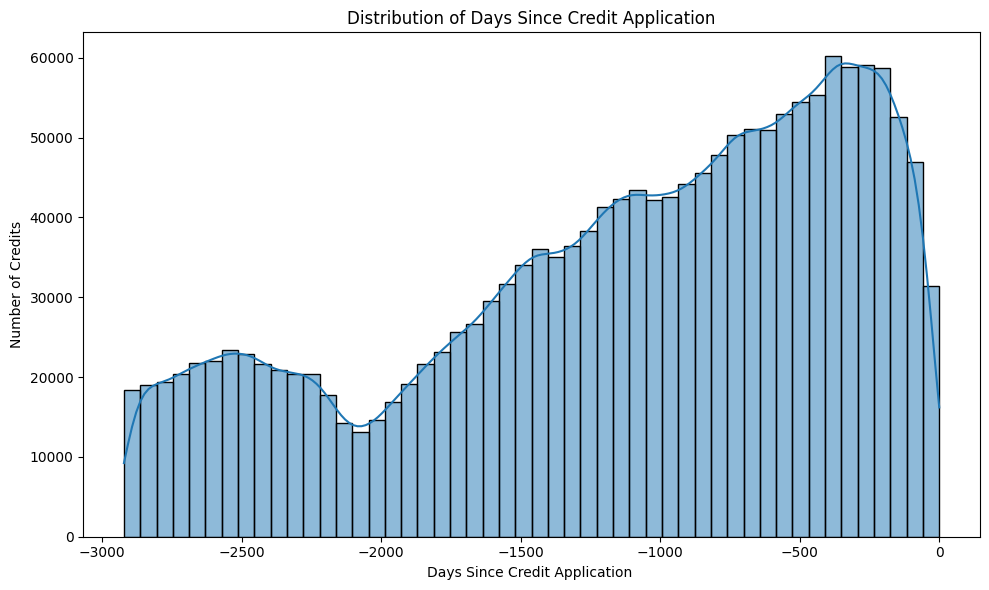

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(bureau["DAYS_CREDIT"], bins=50, kde=True)
plt.title('Distribution of Days Since Credit Application')
plt.xlabel('Days Since Credit Application ')
plt.ylabel('Number of Credits')
plt.tight_layout()
plt.show()

In [ ]:
bureau["DAYS_CREDIT"].describe()

,DAYS_CREDIT
count,1.716428e+06
mean,-1.142108e+03
std,7.951649e+02
min,-2.922000e+03
25%,-1.666000e+03
50%,-9.870000e+02
75%,-4.740000e+02
max,0.000000e+00


### 3. Bureau Balance Data

*This table has one row for each month of the history of every previous loan reported to the Credit Bureau.*

In [ ]:
bbal = pd.read_csv(os.path.join(base_path, 'data/bureau_balance.csv'))
print('Bureau Balance data shape: ', bbal.shape)
bbal.head()

Bureau Balance data shape:  (27299925, 3)


,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


In [ ]:
bbal['SK_ID_BUREAU'].unique().shape[0]

817395

#### 3.1 Checking missing values

In [ ]:
analyze_missing_values(bbal)

,column,dtype,missing_count,missing_pct


#### 3.2 Column Types

In [ ]:
bbal.dtypes.value_counts()

,count
int64,2
object,1


#### 3.3 Categorical Variables

In [ ]:
bbal["STATUS"].value_counts()

,count
STATUS,
C,13646993
0,7499507
X,5810482
1,242347
5,62406
2,23419
3,8924
4,5847


### 4. Previous Applications Data

*The table contains the static data of the previous loan which the client had with Home Credit.*

In [ ]:
prev = pd.read_csv(os.path.join(base_path, 'data/previous_application.csv'))
print('Previous Applications data shape: ', prev.shape)
prev.head()

Previous Applications data shape:  (1670214, 37)


,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
prev['SK_ID_CURR'].nunique() # applicant-level

338857

In [ ]:
prev['SK_ID_PREV'].nunique() # loan-level

1670214

#### 4.1 Checking missing values

In [ ]:
analyze_missing_values(prev)

,column,dtype,missing_count,missing_pct
0,RATE_INTEREST_PRIVILEGED,float64,1664263,99.64
1,RATE_INTEREST_PRIMARY,float64,1664263,99.64
2,AMT_DOWN_PAYMENT,float64,895844,53.64
3,RATE_DOWN_PAYMENT,float64,895844,53.64
4,NAME_TYPE_SUITE,object,820405,49.12
5,DAYS_LAST_DUE,float64,673065,40.30
6,DAYS_FIRST_DRAWING,float64,673065,40.30
7,DAYS_FIRST_DUE,float64,673065,40.30
8,DAYS_TERMINATION,float64,673065,40.30
9,NFLAG_INSURED_ON_APPROVAL,float64,673065,40.30


#### 4.2 Column Types

In [ ]:
prev.dtypes.value_counts()

,count
object,16
float64,15
int64,6


#### 4.3 Categorical Variables

In [ ]:
# Select object (categorical) columns and count unique values using a concise method
prev.select_dtypes('object').apply(pd.Series.nunique, axis=0).sort_values(ascending=False)

,0
NAME_GOODS_CATEGORY,28
NAME_CASH_LOAN_PURPOSE,25
PRODUCT_COMBINATION,17
NAME_SELLER_INDUSTRY,11
CODE_REJECT_REASON,9
CHANNEL_TYPE,8
NAME_TYPE_SUITE,7
WEEKDAY_APPR_PROCESS_START,7
NAME_PORTFOLIO,5
NAME_YIELD_GROUP,5


`NAME_TYPE_SUITE`

In [ ]:
prev['NAME_TYPE_SUITE'].value_counts(normalize=True)

,proportion
NAME_TYPE_SUITE,
Unaccompanied,0.598923
Family,0.250954
"Spouse, partner",0.078922
Children,0.037145
Other_B,0.020739
Other_A,0.010681
Group of people,0.002636


`NAME_GOODS_CATEGORY`

In [ ]:
prev['NAME_GOODS_CATEGORY'].value_counts(normalize=True).round(6)

,proportion
NAME_GOODS_CATEGORY,
XNA,0.569274
Mobile,0.134538
Consumer Electronics,0.072791
Computers,0.063327
Audio/Video,0.059538
Furniture,0.032125
Photo / Cinema Equipment,0.014981
Construction Materials,0.014965
Clothing and Accessories,0.014102


`CHANNEL_TYPE`

In [ ]:
prev['CHANNEL_TYPE'].value_counts(normalize=True)

,proportion
CHANNEL_TYPE,
Credit and cash offices,0.431063
Country-wide,0.296184
Stone,0.126980
Regional / Local,0.064978
Contact center,0.042687
AP+ (Cash loan),0.034155
Channel of corporate sales,0.003682
Car dealer,0.000271


`NAME_SELLER_INDUSTRY`

In [ ]:
prev['NAME_SELLER_INDUSTRY'].value_counts(normalize=True)

,proportion
NAME_SELLER_INDUSTRY,
XNA,0.512342
Consumer electronics,0.238451
Connectivity,0.165266
Furniture,0.034636
Construction,0.017831
Clothing,0.014339
Industry,0.011492
Auto technology,0.002988
Jewelry,0.001622


`NAME_CASH_LOAN_PURPOSE`

In [ ]:
prev['NAME_CASH_LOAN_PURPOSE'].value_counts(normalize=True)

,proportion
NAME_CASH_LOAN_PURPOSE,
XAP,0.552421
XNA,0.405887
Repairs,0.014229
Other,0.009345
Urgent needs,0.005036
Buying a used car,0.001729
Building a house or an annex,0.001612
Everyday expenses,0.001447
Medicine,0.001302


`WEEKDAY_APPR_PROCESS_START`

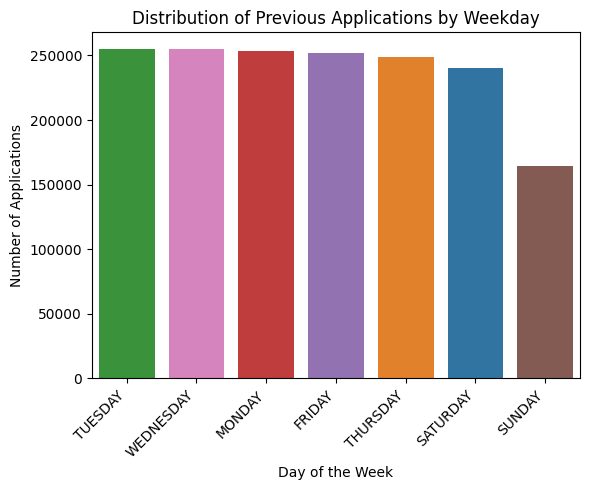

In [ ]:
plt.figure(figsize=(6, 5))
sns.countplot(data=prev, x='WEEKDAY_APPR_PROCESS_START', order=prev['WEEKDAY_APPR_PROCESS_START'].value_counts().index, hue='WEEKDAY_APPR_PROCESS_START', legend=False)
plt.title('Distribution of Previous Applications by Weekday')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Applications')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### 4.4 Numerical Variables

`DAYS_FIRST_DRAWING`

In [ ]:
prev["DAYS_FIRST_DRAWING"].describe()

,DAYS_FIRST_DRAWING
count,997149.000000
mean,342209.855039
std,88916.115834
min,-2922.000000
25%,365243.000000
50%,365243.000000
75%,365243.000000
max,365243.000000


In [ ]:
prev[prev["DAYS_FIRST_DRAWING"]==365243].shape[0]

934444

`CNT_PAYMENT`

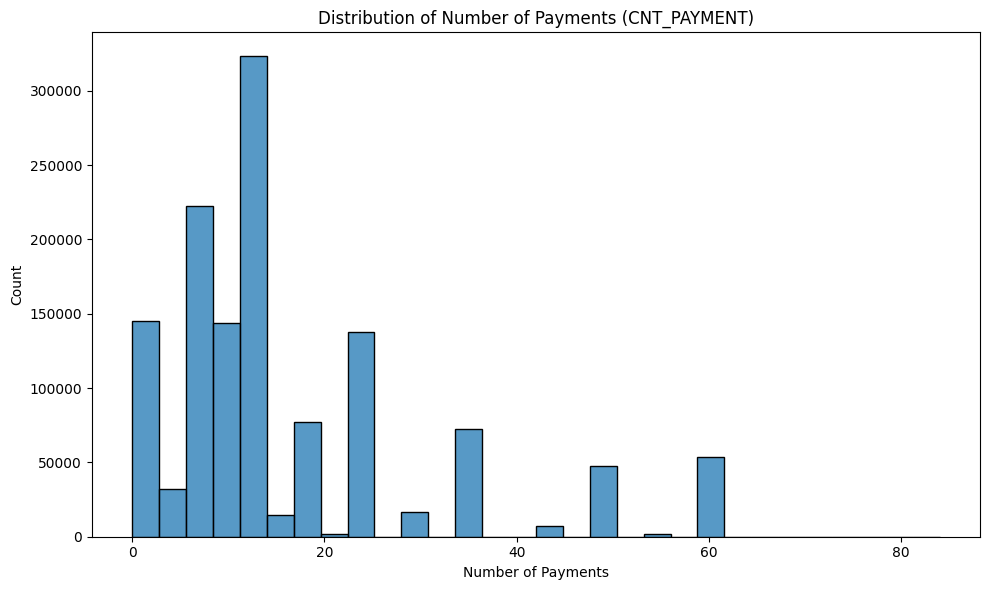

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(prev['CNT_PAYMENT'].dropna(), bins=30)
plt.title('Distribution of Number of Payments (CNT_PAYMENT)')
plt.xlabel('Number of Payments')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 5. POS CASH Balance Data

In [ ]:
pos = pd.read_csv(os.path.join(base_path, 'data/POS_CASH_balance.csv'))
print('POS CASH Balance data shape: ', pos.shape)
pos.head()

POS CASH Balance data shape:  (10001358, 8)


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0


In [ ]:
pos['SK_ID_CURR'].nunique() # applicant-level

337252

#### 5.1 Checking missing values

In [ ]:
analyze_missing_values(pos)

,column,dtype,missing_count,missing_pct
0,CNT_INSTALMENT_FUTURE,float64,26087,0.26
1,CNT_INSTALMENT,float64,26071,0.26


#### 5.2 Column Types

In [ ]:
pos.dtypes.value_counts()

,count
int64,5
float64,2
object,1


#### 5.3 Categorical Variables

In [ ]:
pos['NAME_CONTRACT_STATUS'].value_counts(normalize=True).round(6)

,proportion
NAME_CONTRACT_STATUS,
Active,0.914988
Completed,0.074478
Signed,0.008725
Demand,0.000706
Returned to the store,0.000546
Approved,0.000492
Amortized debt,0.000064
Canceled,0.000001
XNA,0.000000


#### 5.4 Numerical Variable

In [ ]:
pos['MONTHS_BALANCE'].describe()

,MONTHS_BALANCE
count,1.000136e+07
mean,-3.501259e+01
std,2.606657e+01
min,-9.600000e+01
25%,-5.400000e+01
50%,-2.800000e+01
75%,-1.300000e+01
max,-1.000000e+00


In [ ]:
pos['SK_DPD'].describe()

,SK_DPD
count,1.000136e+07
mean,1.160693e+01
std,1.327140e+02
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,0.000000e+00
max,4.231000e+03


### 6. Installments Payments Data

In [ ]:
inst = pd.read_csv(os.path.join(base_path, 'data/installments_payments.csv'))
print('Installments Payments data shape: ', inst.shape)
inst.head()

Installments Payments data shape:  (13605401, 8)


,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


In [ ]:
inst['SK_ID_CURR'].nunique()

339587

#### 6.1 Checking missing values

In [ ]:
analyze_missing_values(inst)

,column,dtype,missing_count,missing_pct
0,DAYS_ENTRY_PAYMENT,float64,2905,0.02
1,AMT_PAYMENT,float64,2905,0.02


#### 6.2 Column Types

In [ ]:
inst.dtypes.value_counts()

,count
float64,5
int64,3


#### 6.3 Numerical Variables

In [ ]:
inst['NUM_INSTALMENT_VERSION'].value_counts()

,count
NUM_INSTALMENT_VERSION,
1.0,8485004
0.0,4082498
2.0,620283
3.0,237063
4.0,55274
...,...
54.0,1
55.0,1
56.0,1


In [ ]:
inst['DAYS_INSTALMENT'].describe()

,DAYS_INSTALMENT
count,1.360540e+07
mean,-1.042270e+03
std,8.009463e+02
min,-2.922000e+03
25%,-1.654000e+03
50%,-8.180000e+02
75%,-3.610000e+02
max,-1.000000e+00


In [ ]:
inst['DAYS_ENTRY_PAYMENT'].describe()

,DAYS_ENTRY_PAYMENT
count,1.360250e+07
mean,-1.051114e+03
std,8.005859e+02
min,-4.921000e+03
25%,-1.662000e+03
50%,-8.270000e+02
75%,-3.700000e+02
max,-1.000000e+00


In [ ]:
inst['AMT_INSTALMENT'].describe()

,AMT_INSTALMENT
count,1.360540e+07
mean,1.705091e+04
std,5.057025e+04
min,0.000000e+00
25%,4.226085e+03
50%,8.884080e+03
75%,1.671021e+04
max,3.771488e+06


### 7. Credit Card Balance Data

In [ ]:
card = pd.read_csv(os.path.join(base_path, 'data/credit_card_balance.csv'))
print('Credit Card Balance data shape: ', card.shape)
card.head()

Credit Card Balance data shape:  (3840312, 23)


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,...,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,...,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,...,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,...,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,...,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0


In [ ]:
card['SK_ID_CURR'].nunique()

103558

#### 7.1 Checking missing values

In [ ]:
analyze_missing_values(card)

,column,dtype,missing_count,missing_pct
0,AMT_PAYMENT_CURRENT,float64,767988,20.00
1,AMT_DRAWINGS_ATM_CURRENT,float64,749816,19.52
2,AMT_DRAWINGS_OTHER_CURRENT,float64,749816,19.52
3,AMT_DRAWINGS_POS_CURRENT,float64,749816,19.52
4,CNT_DRAWINGS_ATM_CURRENT,float64,749816,19.52
5,CNT_DRAWINGS_POS_CURRENT,float64,749816,19.52
6,CNT_DRAWINGS_OTHER_CURRENT,float64,749816,19.52
7,AMT_INST_MIN_REGULARITY,float64,305236,7.95
8,CNT_INSTALMENT_MATURE_CUM,float64,305236,7.95


#### 7.2 Column Types

In [ ]:
card.dtypes.value_counts()

,count
float64,15
int64,7
object,1


#### 7.3 Categorical Variables

In [ ]:
card['NAME_CONTRACT_STATUS'].value_counts(normalize=True)

,proportion
NAME_CONTRACT_STATUS,
Active,0.963056
Completed,0.033570
Signed,0.002879
Demand,0.000355
Sent proposal,0.000134
Refused,0.000004
Approved,0.000001


#### 7.4 Numerical Variables

In [ ]:
card['AMT_BALANCE'].describe()

,AMT_BALANCE
count,3.840312e+06
mean,5.830016e+04
std,1.063070e+05
min,-4.202502e+05
25%,0.000000e+00
50%,0.000000e+00
75%,8.904669e+04
max,1.505902e+06


In [ ]:
card['AMT_CREDIT_LIMIT_ACTUAL'].describe()

,AMT_CREDIT_LIMIT_ACTUAL
count,3.840312e+06
mean,1.538080e+05
std,1.651457e+05
min,0.000000e+00
25%,4.500000e+04
50%,1.125000e+05
75%,1.800000e+05
max,1.350000e+06


In [ ]:
card['AMT_DRAWINGS_ATM_CURRENT'].describe()

,AMT_DRAWINGS_ATM_CURRENT
count,3.090496e+06
mean,5.961325e+03
std,2.822569e+04
min,-6.827310e+03
25%,0.000000e+00
50%,0.000000e+00
75%,0.000000e+00
max,2.115000e+06


In [ ]:
card['AMT_PAYMENT_CURRENT'].describe()

,AMT_PAYMENT_CURRENT
count,3.072324e+06
mean,1.028054e+04
std,3.607808e+04
min,0.000000e+00
25%,1.523700e+02
50%,2.702700e+03
75%,9.000000e+03
max,4.289207e+06


In [ ]:
card['SK_DPD'].describe()

,SK_DPD
count,3.840312e+06
mean,9.283667e+00
std,9.751570e+01
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,0.000000e+00
max,3.260000e+03


In [ ]:
card['MONTHS_BALANCE'].describe()

,MONTHS_BALANCE
count,3.840312e+06
mean,-3.452192e+01
std,2.666775e+01
min,-9.600000e+01
25%,-5.500000e+01
50%,-2.800000e+01
75%,-1.100000e+01
max,-1.000000e+00


## Feature Engineering

In [ ]:
def rare_encode(df, cols=None, threshold=0.01):
  """
  Replaces infrequent categories in categorical columns with 'Other'.

  Categories whose relative frequency is below `threshold` are grouped
  into a single 'Other' category.

  Returns:
      pd.DataFrame: DataFrame with rare categories encoded.
  """
  out = df.copy()

  # Decide which columns to process
  if cols is None:
      cols = out.select_dtypes(include=["object"]).columns

  for col in cols:
      freq = out[col].value_counts(normalize=True, dropna=False)
      rare_levels = freq[freq < threshold].index

      if len(rare_levels) > 0:
          out[col] = out[col].where(~out[col].isin(rare_levels), "Other")

  return out

In [ ]:
def one_hot_encode_clean(df, nan_as_category=False):
  """
  One-hot encodes categorical columns and cleans column names.

  Detects object-type columns, applies one-hot encoding (optionally
  treating NaNs as a category), and sanitizes column names to
  uppercase alphanumeric format.

  Returns:
      Tuple[pd.DataFrame, List[str]]: Encoded DataFrame and list of
      resulting dummy column names.
  """
  out = df.copy()

  # Identify categorical columns
  cat_cols = out.select_dtypes(include="object").columns.tolist()

  # One-hot encode
  out = pd.get_dummies(out, columns=cat_cols, dummy_na=nan_as_category)

  # Sanitize column names
  out.columns = (out.columns.str.replace(r"[^A-Za-z0-9_]+", "_", regex=True)
                            .str.upper())

  # Identify resulting dummy columns
  encoded_cat_cols = [c for c in out.columns
                      if any(c.startswith(col.upper() + "_") for col in cat_cols)]

  return out, encoded_cat_cols

### 1. Application Data (train, test)

In [ ]:
def feature_eng_app_data(df, nan_as_category=True):
    """
    Feature engineering for application_train/test.csv.

    - Cleans obvious invalid categories and anomalies
    - Caps outliers, builds ratio/flag/aggregate features
    - Reduces sparsity (rare encoding + simple remaps)
    - Encodes categoricals (binary label + one-hot)

    Returns:
        pd.DataFrame: Engineered features with SK_ID_CURR as index.
    """
    df = df.copy()

    # 1) Basic cleaning
    df = df[(df["CODE_GENDER"] != "XNA") & (df["NAME_FAMILY_STATUS"] != "Unknown")].copy()
    df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)  # known anomaly

    # 2) Cap a few outliers
    df["OWN_CAR_AGE"] = df["OWN_CAR_AGE"].clip(upper=50)
    df["CNT_CHILDREN"] = df["CNT_CHILDREN"].clip(upper=6)

    # 3) New numeric features
    df["R_EMPLOYED_TO_AGE"] = df["DAYS_EMPLOYED"] / df["DAYS_BIRTH"]
    df["R_INCOME_TO_CREDIT"] = df["AMT_INCOME_TOTAL"] / df["AMT_CREDIT"]
    df["INCOME_PER_PERSON"] = df["AMT_INCOME_TOTAL"] / df["CNT_FAM_MEMBERS"]

    df["R_ANNUITY_TO_CREDIT"] = df["AMT_ANNUITY"] / df["AMT_CREDIT"]
    df["R_CREDIT_TO_GOODS"] = df["AMT_CREDIT"] / df["AMT_GOODS_PRICE"]
    df["FLAG_CREDIT_GT_GOODS"] = (df["AMT_CREDIT"] > df["AMT_GOODS_PRICE"]).astype("int8")

    # 4) Stabilize heavy-tailed money vars
    for col in ["AMT_CREDIT", "AMT_INCOME_TOTAL", "AMT_GOODS_PRICE", "AMT_ANNUITY"]:
        if col in df.columns:
            df[col] = np.log1p(df[col].abs())

    # 5) Simple aggregations / counts
    df["CONTACT_SCORE"] = (df["FLAG_MOBIL"] + df["FLAG_EMP_PHONE"] + df["FLAG_WORK_PHONE"]
                           + df["FLAG_CONT_MOBILE"] + df["FLAG_EMAIL"]).astype("int16")

    doc_cols = [f"FLAG_DOCUMENT_{i}" for i in range(2, 22)]
    df["DOC_MISS_COUNT"] = df[doc_cols].sum(axis=1).astype("int16")
    df["FLAG_DOC_MISSING"] = (df["DOC_MISS_COUNT"] > 0).astype("int8")

    req_cols = [
        "AMT_REQ_CREDIT_BUREAU_HOUR",
        "AMT_REQ_CREDIT_BUREAU_DAY",
        "AMT_REQ_CREDIT_BUREAU_WEEK",
        "AMT_REQ_CREDIT_BUREAU_MON",
        "AMT_REQ_CREDIT_BUREAU_QRT",
        "AMT_REQ_CREDIT_BUREAU_YEAR"
    ]
    df["BUREAU_REQ_TOTAL"] = df[req_cols].sum(axis=1).clip(upper=7)

    # 6) Drop low-signal columns
    drop_list = [
        "AMT_REQ_CREDIT_BUREAU_DAY",
        "AMT_REQ_CREDIT_BUREAU_HOUR",
        "AMT_REQ_CREDIT_BUREAU_MON",
        "AMT_REQ_CREDIT_BUREAU_QRT",
        "AMT_REQ_CREDIT_BUREAU_WEEK",
        "AMT_REQ_CREDIT_BUREAU_YEAR",
        "APARTMENTS_AVG",
        "APARTMENTS_MEDI",
        "APARTMENTS_MODE",
        "BASEMENTAREA_AVG",
        "BASEMENTAREA_MEDI",
        "BASEMENTAREA_MODE",
        "COMMONAREA_AVG",
        "COMMONAREA_MEDI",
        "COMMONAREA_MODE",
        "CNT_FAM_MEMBERS",
        "DAYS_LAST_PHONE_CHANGE",
        "DEF_60_CNT_SOCIAL_CIRCLE",
        "ELEVATORS_AVG",
        "ELEVATORS_MEDI",
        "ELEVATORS_MODE",
        "EMERGENCYSTATE_MODE",
        "ENTRANCES_AVG",
        "ENTRANCES_MEDI",
        "ENTRANCES_MODE",
        "FLAG_CONT_MOBILE",
        "FLAG_DOCUMENT_3",
        "FLAG_DOCUMENT_4",
        "FLAG_DOCUMENT_5",
        "FLAG_DOCUMENT_6",
        "FLAG_DOCUMENT_7",
        "FLAG_DOCUMENT_8",
        "FLAG_DOCUMENT_9",
        "FLAG_DOCUMENT_10",
        "FLAG_DOCUMENT_11",
        "FLAG_DOCUMENT_12",
        "FLAG_DOCUMENT_13",
        "FLAG_DOCUMENT_14",
        "FLAG_DOCUMENT_15",
        "FLAG_DOCUMENT_16",
        "FLAG_DOCUMENT_17",
        "FLAG_DOCUMENT_18",
        "FLAG_DOCUMENT_19",
        "FLAG_DOCUMENT_2",
        "FLAG_DOCUMENT_20",
        "FLAG_DOCUMENT_21",
        "FLAG_EMAIL",
        "FLAG_EMP_PHONE",
        "FLAG_MOBIL",
        "FLAG_PHONE",
        "FLAG_WORK_PHONE",
        "FLOORSMAX_AVG",
        "FLOORSMAX_MEDI",
        "FLOORSMAX_MODE",
        "FLOORSMIN_AVG",
        "FLOORSMIN_MEDI",
        "FLOORSMIN_MODE",
        "FONDKAPREMONT_MODE",
        "HOUSETYPE_MODE",
        "LANDAREA_AVG",
        "LANDAREA_MEDI",
        "LANDAREA_MODE",
        "LIVE_REGION_NOT_WORK_REGION",
        "LIVINGAPARTMENTS_AVG",
        "LIVINGAPARTMENTS_MEDI",
        "LIVINGAPARTMENTS_MODE",
        "LIVINGAREA_AVG",
        "LIVINGAREA_MEDI",
        "LIVINGAREA_MODE",
        "NONLIVINGAPARTMENTS_AVG",
        "NONLIVINGAPARTMENTS_MEDI",
        "NONLIVINGAPARTMENTS_MODE",
        "NONLIVINGAREA_AVG",
        "NONLIVINGAREA_MEDI",
        "NONLIVINGAREA_MODE",
        "OBS_60_CNT_SOCIAL_CIRCLE",
        "REGION_RATING_CLIENT_W_CITY",
        "REG_REGION_NOT_LIVE_REGION",
        "REG_REGION_NOT_WORK_REGION",
        "TOTALAREA_MODE",
        "WALLSMATERIAL_MODE",
        "YEARS_BEGINEXPLUATATION_AVG",
        "YEARS_BEGINEXPLUATATION_MEDI",
        "YEARS_BEGINEXPLUATATION_MODE",
        "YEARS_BUILD_AVG",
        "YEARS_BUILD_MEDI",
        "YEARS_BUILD_MODE"
    ]

    df = df.drop(columns=drop_list, errors="ignore")

    # 7) Reduce sparsity in a few categoricals
    df = rare_encode(df, cols=["NAME_INCOME_TYPE"])
    df["WEEKDAY_APPR_PROCESS_START"] = df["WEEKDAY_APPR_PROCESS_START"].replace(
        {
            "MONDAY": "WEEKDAY",
            "TUESDAY": "WEEKDAY",
            "WEDNESDAY": "WEEKDAY",
            "THURSDAY": "WEEKDAY",
            "FRIDAY": "WEEKDAY",
            "SATURDAY": "WEEKEND",
            "SUNDAY": "WEEKEND",
        }
    )

    # 8) Encode categoricals: Label Encoding for binary, OHE for the rest
    obj_cols = df.select_dtypes(include="object").columns
    binary_cols = [c for c in obj_cols if df[c].nunique(dropna=True) == 2 and
                   df[c].isna().sum() == 0]

    for c in binary_cols:
        levels = sorted(df[c].astype(str).unique())
        df[c] = df[c].astype(str).map({levels[0]: 0, levels[1]: 1}).astype("int8")

    df, _ = one_hot_encode_clean(df, nan_as_category=nan_as_category)

    df = df.set_index("SK_ID_CURR")

    return df

In [ ]:
# Add placeholder TARGET to test so schemas align
app_test["TARGET"] = np.nan

# Merge train + test vertically
app_all = pd.concat([app_train, app_test], axis=0, ignore_index=True)

# Preprocess application_train/test.csv
app_all_fe = feature_eng_app_data(app_all)

#### Missing values

In [ ]:
analyze_missing_values(app_all_fe)

,column,dtype,missing_count,missing_pct
0,OWN_CAR_AGE,float64,235237,66.03
1,EXT_SOURCE_1,float64,193907,54.43
2,EXT_SOURCE_3,float64,69632,19.55
3,DAYS_EMPLOYED,float64,64648,18.15
4,R_EMPLOYED_TO_AGE,float64,64648,18.15
5,TARGET,float64,48744,13.68
6,OBS_30_CNT_SOCIAL_CIRCLE,float64,1050,0.29
7,DEF_30_CNT_SOCIAL_CIRCLE,float64,1050,0.29
8,EXT_SOURCE_2,float64,668,0.19
9,R_CREDIT_TO_GOODS,float64,276,0.08


### 2. Bureau and Bureau Balance Data




In [ ]:
def feature_eng_bureau(bureau):
    """
    Feature engineering for bureau.csv at the bureau-loan row level (SK_ID_BUREAU).

    Computes applicant-level aggregates (groupby SK_ID_CURR) like counts/shares/ratios,
    then broadcasts them back onto each loan row.

    Returns:
        pd.DataFrame: Loan-level bureau table (one row per SK_ID_BUREAU).
    """
    out = bureau.copy()
    g = out.groupby("SK_ID_CURR", sort=False)

    # Counts / diversity
    out["NEW_LOAN_COUNT"] = g["SK_ID_BUREAU"].transform("count")
    out["NEW_CREDIT_TYPE_NUNIQUE"] = g["CREDIT_TYPE"].transform("nunique")

    # Shares (treat NaN as not active/not future)
    is_active = (out["CREDIT_ACTIVE"].fillna("Unknown") == "Active").astype("int8")
    out["NEW_ACTIVE_SHARE"] = is_active.groupby(out["SK_ID_CURR"]).transform("mean")

    has_future_end = (out["DAYS_CREDIT_ENDDATE"].fillna(-np.inf) > 0).astype("int8")
    out["NEW_FUTURE_ENDDATE_SHARE"] = has_future_end.groupby(out["SK_ID_CURR"]).transform("mean")

    # Debt-to-credit ratio
    debt_col = "AMT_CREDIT_SUM_DEBT"
    credit_col = "AMT_CREDIT_SUM"

    if debt_col in out.columns:
        out[debt_col] = out[debt_col].fillna(0)
        total_debt = g[debt_col].transform("sum")
    else:
        total_debt = 0.0

    if credit_col in out.columns:
        out[credit_col] = out[credit_col].fillna(0)
        total_credit = g[credit_col].transform("sum")
    else:
        total_credit = 0.0

    out["NEW_DEBT_TO_CREDIT"] = 0.0
    has_credit = total_credit > 0
    out.loc[has_credit, "NEW_DEBT_TO_CREDIT"] = (total_debt[has_credit] / total_credit[has_credit]).astype(float)

    return out

In [ ]:
def feature_eng_bbal(bbal):
    """
    Feature engineering for bureau_balance.csv aggregated to the loan level (SK_ID_BUREAU).

    - One-hot encodes STATUS so mean() becomes share of months in each status
    - Aggregates MONTHS_BALANCE to describe history length/coverage per loan

    Returns:
        pd.DataFrame: Loan-level bureau_balance features (one row per SK_ID_BUREAU).
    """
    bb = bbal.copy()

    # One-hot-encoding
    if "STATUS" in bb.columns:
        bb = pd.get_dummies(bb, columns=["STATUS"], dummy_na=False)

    g = bb.groupby("SK_ID_BUREAU", sort=False)

    # Coverage over time (months)
    bb_loan = (g["MONTHS_BALANCE"].agg(BB_MONTHS_MIN="min", BB_MONTHS_MAX="max",
                                      BB_MONTHS_COUNT="size").reset_index())

    # Status proportions per loan (mean of one-hot columns)
    status_cols = [c for c in bb.columns if c.startswith("STATUS_")]
    for c in status_cols:
        bb_loan[f"BB_{c.upper()}_MEAN"] = g[c].mean().values

    return bb_loan

In [ ]:
def build_bureau_applicant_table(bureau, bbal, nan_as_category=False):
    """
    Builds an applicant-level (SK_ID_CURR) feature table from bureau + bureau_balance.

    Pipeline:
      1) Feature engineer bureau.csv at loan-row level
      2) Aggregate bureau_balance.csv to loan-row level
      3) Merge bureau + bureau_balance at loan-row level (SK_ID_BUREAU)
      4) Rare-encode categoricals to reduce sparsity
      5) One-hot encode categoricals
      6) Aggregate loan-level rows to applicant level:
         - numeric cols: selected min/max/mean/sum
         - dummy cols: mean()

    Returns:
        pd.DataFrame: Applicant-level bureau feature table indexed by SK_ID_CURR.
    """

    # 1) Bureau (loan-row level)
    bureau_fe = feature_eng_bureau(bureau)

    # 2) Bureau balance (loan-row level)
    bb_loan = feature_eng_bbal(bbal)

    # 3) Merge at loan level
    bureau_full = bureau_fe.merge(bb_loan, on="SK_ID_BUREAU", how="left")

    # 4) Rare encoding
    bureau_full = rare_encode(bureau_full)

    # 5) One-hot encode categoricals
    bureau_full, cat_cols = one_hot_encode_clean(bureau_full, nan_as_category=nan_as_category)

    # 6) Aggregate loan to applicant level

    # 6.1) Numeric aggregations
    agg_spec = {
        "DAYS_CREDIT": ["min", "max"],
        "DAYS_CREDIT_ENDDATE": ["min", "max"],
        "DAYS_CREDIT_UPDATE": ["mean"],
        "CREDIT_DAY_OVERDUE": ["max"],

        "AMT_CREDIT_MAX_OVERDUE": ["mean"],
        "AMT_CREDIT_SUM": ["mean"],
        "AMT_CREDIT_SUM_DEBT": ["max"],
        "AMT_CREDIT_SUM_OVERDUE": ["max"],
        "AMT_CREDIT_SUM_LIMIT": ["mean"],
        "AMT_ANNUITY": ["mean"],

        "CNT_CREDIT_PROLONG": ["sum"],

        "BB_MONTHS_MIN": ["min"],
        "BB_MONTHS_MAX": ["max"],
        "BB_MONTHS_COUNT": ["max"],

        "NEW_LOAN_COUNT": ["max"],
        "NEW_CREDIT_TYPE_NUNIQUE": ["max"],
        "NEW_ACTIVE_SHARE": ["max"],
        "NEW_FUTURE_ENDDATE_SHARE": ["max"],
        "NEW_DEBT_TO_CREDIT": ["max"],
    }

    # 6.2) Dummies aggregations (mean)
    id_cols = {"SK_ID_CURR", "SK_ID_BUREAU"}
    for c in cat_cols:
        if c in bureau_full.columns and c not in id_cols:
            agg_spec[c] = ["mean"]

    app = bureau_full.groupby("SK_ID_CURR", sort=False).agg(agg_spec)

    # Flatten MultiIndex columns to BUREAU_<COL>_<AGG>
    app.columns = [f"BUREAU_{col}_{stat.upper()}" for (col, stat) in app.columns]

    return app

In [ ]:
# Preprocess bureau.csv and burea_balance.csv
bureau_app = build_bureau_applicant_table(bureau, bbal)

In [ ]:
bureau_app

,BUREAU_DAYS_CREDIT_MIN,BUREAU_DAYS_CREDIT_MAX,BUREAU_DAYS_CREDIT_ENDDATE_MIN,BUREAU_DAYS_CREDIT_ENDDATE_MAX,BUREAU_DAYS_CREDIT_UPDATE_MEAN,BUREAU_CREDIT_DAY_OVERDUE_MAX,BUREAU_AMT_CREDIT_MAX_OVERDUE_MEAN,BUREAU_AMT_CREDIT_SUM_MEAN,BUREAU_AMT_CREDIT_SUM_DEBT_MAX,BUREAU_AMT_CREDIT_SUM_OVERDUE_MAX,...,BUREAU_CREDIT_ACTIVE_ACTIVE_MEAN,BUREAU_CREDIT_ACTIVE_CLOSED_MEAN,BUREAU_CREDIT_ACTIVE_OTHER_MEAN,BUREAU_CREDIT_CURRENCY_OTHER_MEAN,BUREAU_CREDIT_CURRENCY_CURRENCY_1_MEAN,BUREAU_CREDIT_TYPE_CAR_LOAN_MEAN,BUREAU_CREDIT_TYPE_CONSUMER_CREDIT_MEAN,BUREAU_CREDIT_TYPE_CREDIT_CARD_MEAN,BUREAU_CREDIT_TYPE_MORTGAGE_MEAN,BUREAU_CREDIT_TYPE_OTHER_MEAN
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
215354,-1872,-43,-1089.0,27460.0,-367.272727,0,25891.500,5.430859e+05,171342.0,0.0,...,0.545455,0.454545,0.0,0.0,1.0,0.090909,0.636364,0.272727,0.000000,0.0
162297,-2456,-277,-1684.0,5261.0,-777.833333,0,2997.000,1.371731e+06,0.0,0.0,...,0.500000,0.500000,0.0,0.0,1.0,0.000000,0.500000,0.333333,0.166667,0.0
402440,-96,-96,269.0,269.0,-22.000000,0,0.000,8.991000e+04,76905.0,0.0,...,1.000000,0.000000,0.0,0.0,1.0,0.000000,1.000000,0.000000,0.000000,0.0
238881,-2911,-95,-2607.0,1720.0,-530.625000,0,0.000,1.606549e+05,520920.0,0.0,...,0.375000,0.625000,0.0,0.0,1.0,0.000000,0.625000,0.375000,0.000000,0.0
222183,-2744,-315,-2561.0,1512.0,-618.875000,0,21924.954,8.948700e+05,1185493.5,0.0,...,0.625000,0.375000,0.0,0.0,1.0,0.125000,0.500000,0.375000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207190,-532,-532,45.0,45.0,-31.000000,0,NaN,4.500000e+05,0.0,0.0,...,0.000000,1.000000,0.0,0.0,1.0,0.000000,1.000000,0.000000,0.000000,0.0
324956,-381,-381,-199.0,-199.0,-199.000000,0,0.000,1.980000e+04,0.0,0.0,...,0.000000,1.000000,0.0,0.0,1.0,0.000000,1.000000,0.000000,0.000000,0.0
448157,-1441,-1441,2197.0,2197.0,-2.000000,0,NaN,1.800000e+06,1076809.5,0.0,...,1.000000,0.000000,0.0,0.0,1.0,0.000000,0.000000,0.000000,1.000000,0.0


#### Columns

In [ ]:
bureau_app.columns

Index(['BUREAU_DAYS_CREDIT_MIN', 'BUREAU_DAYS_CREDIT_MAX',
       'BUREAU_DAYS_CREDIT_ENDDATE_MIN', 'BUREAU_DAYS_CREDIT_ENDDATE_MAX',
       'BUREAU_DAYS_CREDIT_UPDATE_MEAN', 'BUREAU_CREDIT_DAY_OVERDUE_MAX',
       'BUREAU_AMT_CREDIT_MAX_OVERDUE_MEAN', 'BUREAU_AMT_CREDIT_SUM_MEAN',
       'BUREAU_AMT_CREDIT_SUM_DEBT_MAX', 'BUREAU_AMT_CREDIT_SUM_OVERDUE_MAX',
       'BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN', 'BUREAU_AMT_ANNUITY_MEAN',
       'BUREAU_CNT_CREDIT_PROLONG_SUM', 'BUREAU_BB_MONTHS_MIN_MIN',
       'BUREAU_BB_MONTHS_MAX_MAX', 'BUREAU_BB_MONTHS_COUNT_MAX',
       'BUREAU_NEW_LOAN_COUNT_MAX', 'BUREAU_NEW_CREDIT_TYPE_NUNIQUE_MAX',
       'BUREAU_NEW_ACTIVE_SHARE_MAX', 'BUREAU_NEW_FUTURE_ENDDATE_SHARE_MAX',
       'BUREAU_NEW_DEBT_TO_CREDIT_MAX', 'BUREAU_CREDIT_ACTIVE_ACTIVE_MEAN',
       'BUREAU_CREDIT_ACTIVE_CLOSED_MEAN', 'BUREAU_CREDIT_ACTIVE_OTHER_MEAN',
       'BUREAU_CREDIT_CURRENCY_OTHER_MEAN',
       'BUREAU_CREDIT_CURRENCY_CURRENCY_1_MEAN',
       'BUREAU_CREDIT_TYPE_CAR_LOAN_ME

#### Missing Values

In [ ]:
analyze_missing_values(bureau_app)

,column,dtype,missing_count,missing_pct
0,BUREAU_AMT_ANNUITY_MEAN,float64,187587,61.34
1,BUREAU_BB_MONTHS_COUNT_MAX,float64,171269,56.00
2,BUREAU_BB_MONTHS_MIN_MIN,float64,171269,56.00
3,BUREAU_BB_MONTHS_MAX_MAX,float64,171269,56.00
4,BUREAU_AMT_CREDIT_MAX_OVERDUE_MEAN,float64,92840,30.36
5,BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN,float64,25308,8.28
6,BUREAU_DAYS_CREDIT_ENDDATE_MIN,float64,2585,0.85
7,BUREAU_DAYS_CREDIT_ENDDATE_MAX,float64,2585,0.85


### 3. Previous Applications Data

In [ ]:
def feature_eng_prev(prev):
    """
    Feature engineering for previous_application.csv at the loan-application row level (SK_ID_PREV).

    Cleans known anomalies/missing-heavy columns, reduces weekday cardinality, and creates
    ratio/interest/time-delta features for downstream aggregation to applicant level.

    Returns:
        pd.DataFrame: Previous-application-level table with engineered features.
    """
    out = prev.copy()

    # Drop very high-missing cols
    out = out.drop(columns=["RATE_INTEREST_PRIVILEGED", "RATE_INTEREST_PRIMARY"], errors="ignore")

    # Replace sentinel anomalies with NaN
    anomaly_cols = ["DAYS_FIRST_DRAWING", "DAYS_FIRST_DUE", "DAYS_LAST_DUE_1ST_VERSION",
                    "DAYS_LAST_DUE", "DAYS_TERMINATION"]
    out[anomaly_cols] = out[anomaly_cols].replace(365243, np.nan)

    # Reduce weekday levels
    out["WEEKDAY_APPR_PROCESS_START"] = out["WEEKDAY_APPR_PROCESS_START"].replace({
        "MONDAY": "WEEKDAY",
        "TUESDAY": "WEEKDAY",
        "WEDNESDAY": "WEEKDAY",
        "THURSDAY": "WEEKDAY",
        "FRIDAY": "WEEKDAY",
        "SATURDAY": "WEEKEND",
        "SUNDAY": "WEEKEND",
    })

    # Ratios
    out["NEW_APP_CREDIT_RATE"] = out["AMT_APPLICATION"] / out["AMT_CREDIT"]
    out["NEW_AMT_PAYMENT_RATE"] = out["AMT_CREDIT"] / out["AMT_ANNUITY"]
    out["NEW_APP_GOODS_RATE"] = out["AMT_APPLICATION"] / out["AMT_GOODS_PRICE"]
    out["NEW_CREDIT_GOODS_RATE"] = out["AMT_CREDIT"] / out["AMT_GOODS_PRICE"]

    # Interest proxies
    out["NEW_INTEREST"] = out["CNT_PAYMENT"] * out["AMT_ANNUITY"] - out["AMT_CREDIT"]
    out["NEW_INTEREST_RATE"] = 2 * 12 * out["NEW_INTEREST"] / (out["AMT_CREDIT"] * (out["CNT_PAYMENT"] + 1))
    out["NEW_INTEREST_SHARE"] = out["NEW_INTEREST"] / out["AMT_CREDIT"]

    # Time delta
    out["NEW_END_DIFF"] = out["DAYS_TERMINATION"] - out["DAYS_LAST_DUE"]

    return out

In [ ]:
def build_prev_applicant_table(prev, nan_as_category=False):
    """
    Builds an applicant-level (SK_ID_CURR) feature table from previous_application.csv.

    Pipeline:
      1) Create loan-level features (SK_ID_PREV rows)
      2) Collapse rare categories (reduce OHE sparsity)
      3) Encode categoricals (binary label + one-hot)
      4) Aggregate loan-level rows -> applicant level (numeric stats + mean of dummies)

    Returns:
      pd.DataFrame: Applicant-level table indexed by SK_ID_CURR.
    """
    df = prev.copy()

    # 1) Loan-level feature engineerin
    df = feature_eng_prev(df)

    # 2) Rare category collapsing
    rare_cols = ["NAME_TYPE_SUITE", "NAME_GOODS_CATEGORY", "CHANNEL_TYPE",
                 "NAME_SELLER_INDUSTRY", "NAME_CASH_LOAN_PURPOSE"]
    df = rare_encode(df, cols=rare_cols)

    # 3) Encode categoricals
    object_cols = df.select_dtypes(include="object").columns

    # Binary categoricals (2 levels, no NaNs)
    binary_cols = [c for c in object_cols if df[c].nunique(dropna=True) == 2 and
                   df[c].isna().sum() == 0]

    # Label encoding for binary cols
    for c in binary_cols:
        levels = sorted(df[c].astype(str).unique())
        df[c] = df[c].astype(str).map({levels[0]: 0, levels[1]: 1}).astype("int8")

    # One-hot encode remaining categoricals
    df, cat_cols = one_hot_encode_clean(df, nan_as_category=nan_as_category)

    # 4) Aggregate to applicant level

    # Numeric aggregations
    agg_spec = {
        "SK_ID_PREV": ["count"],

        "AMT_ANNUITY": ["min", "max", "mean"],
        "AMT_APPLICATION": ["min", "max", "mean"],
        "AMT_CREDIT": ["min", "max", "mean"],
        "AMT_DOWN_PAYMENT": ["min", "max", "mean"],
        "AMT_GOODS_PRICE": ["min", "max", "mean"],

        "HOUR_APPR_PROCESS_START": ["min", "max", "mean"],
        "RATE_DOWN_PAYMENT": ["min", "max", "mean"],
        "DAYS_DECISION": ["min", "max", "mean"],

        "NEW_APP_CREDIT_RATE": ["min", "max", "mean"],
        "NEW_CREDIT_GOODS_RATE": ["min", "max", "mean"],
        "NEW_END_DIFF": ["min", "max", "mean"],
        "NEW_INTEREST": ["min", "max", "mean"],
        "NEW_INTEREST_RATE": ["min", "max", "mean"],
        "NEW_INTEREST_SHARE": ["min", "max", "mean"],
    }

    # Dummies aggregation (mean)
    id_cols = {"SK_ID_CURR", "SK_ID_PREV"}
    for c in list(binary_cols) + list(cat_cols):
        if c in df.columns and c not in id_cols:
            agg_spec[c] = ["mean"]

    app = df.groupby("SK_ID_CURR", sort=False).agg(agg_spec)

    # Flatten MultiIndex columns to PREV_<COL>_<AGG>
    app.columns = [f"PREV_{col}_{stat.upper()}" for (col, stat) in app.columns]

    return app

In [ ]:
# Preprocess prevoius_application.csv
prev_app = build_prev_applicant_table(prev)

In [ ]:
prev_app

,PREV_SK_ID_PREV_COUNT,PREV_AMT_ANNUITY_MIN,PREV_AMT_ANNUITY_MAX,PREV_AMT_ANNUITY_MEAN,PREV_AMT_APPLICATION_MIN,PREV_AMT_APPLICATION_MAX,PREV_AMT_APPLICATION_MEAN,PREV_AMT_CREDIT_MIN,PREV_AMT_CREDIT_MAX,PREV_AMT_CREDIT_MEAN,...,PREV_PRODUCT_COMBINATION_CASH_X_SELL_LOW_MEAN,PREV_PRODUCT_COMBINATION_CASH_X_SELL_MIDDLE_MEAN,PREV_PRODUCT_COMBINATION_POS_HOUSEHOLD_WITH_INTEREST_MEAN,PREV_PRODUCT_COMBINATION_POS_HOUSEHOLD_WITHOUT_INTEREST_MEAN,PREV_PRODUCT_COMBINATION_POS_INDUSTRY_WITH_INTEREST_MEAN,PREV_PRODUCT_COMBINATION_POS_INDUSTRY_WITHOUT_INTEREST_MEAN,PREV_PRODUCT_COMBINATION_POS_MOBILE_WITH_INTEREST_MEAN,PREV_PRODUCT_COMBINATION_POS_MOBILE_WITHOUT_INTEREST_MEAN,PREV_PRODUCT_COMBINATION_POS_OTHER_WITH_INTEREST_MEAN,PREV_PRODUCT_COMBINATION_POS_OTHERS_WITHOUT_INTEREST_MEAN
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
271877,3,1730.430,68258.655,27468.825000,17145.0,1800000.0,641848.500000,17145.0,1754721.0,630571.500,...,0.000000,0.000000,0.000000,0.000000,0.666667,0.0,0.333333,0.0,0.0,0.0
108129,6,4830.930,25188.615,13039.485000,0.0,607500.0,201525.750000,23688.0,679671.0,257522.250,...,0.333333,0.000000,0.166667,0.000000,0.333333,0.0,0.000000,0.0,0.0,0.0
122040,4,6300.000,15060.735,9623.115000,0.0,112500.0,66690.000000,0.0,136444.5,72696.375,...,0.000000,0.000000,0.250000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0
176158,23,10519.965,56907.675,28022.556429,0.0,675000.0,259704.997826,0.0,709749.0,272578.500,...,0.000000,0.217391,0.000000,0.043478,0.000000,0.0,0.000000,0.0,0.0,0.0
202054,25,3020.535,42778.845,21187.627941,0.0,675000.0,179037.720000,0.0,744498.0,208061.640,...,0.000000,0.120000,0.200000,0.000000,0.000000,0.0,0.040000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239799,1,4716.495,4716.495,4716.495000,46800.0,46800.0,46800.000000,46800.0,46800.0,46800.000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.0,0.000000,0.0,0.0,0.0
174832,1,30439.305,30439.305,30439.305000,243000.0,243000.0,243000.000000,289732.5,289732.5,289732.500,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0
253940,1,26084.700,26084.700,26084.700000,135000.0,135000.0,135000.000000,135000.0,135000.0,135000.000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0


#### Columns

In [ ]:
prev_app.columns

Index(['PREV_SK_ID_PREV_COUNT', 'PREV_AMT_ANNUITY_MIN', 'PREV_AMT_ANNUITY_MAX',
       'PREV_AMT_ANNUITY_MEAN', 'PREV_AMT_APPLICATION_MIN',
       'PREV_AMT_APPLICATION_MAX', 'PREV_AMT_APPLICATION_MEAN',
       'PREV_AMT_CREDIT_MIN', 'PREV_AMT_CREDIT_MAX', 'PREV_AMT_CREDIT_MEAN',
       ...
       'PREV_PRODUCT_COMBINATION_CASH_X_SELL_LOW_MEAN',
       'PREV_PRODUCT_COMBINATION_CASH_X_SELL_MIDDLE_MEAN',
       'PREV_PRODUCT_COMBINATION_POS_HOUSEHOLD_WITH_INTEREST_MEAN',
       'PREV_PRODUCT_COMBINATION_POS_HOUSEHOLD_WITHOUT_INTEREST_MEAN',
       'PREV_PRODUCT_COMBINATION_POS_INDUSTRY_WITH_INTEREST_MEAN',
       'PREV_PRODUCT_COMBINATION_POS_INDUSTRY_WITHOUT_INTEREST_MEAN',
       'PREV_PRODUCT_COMBINATION_POS_MOBILE_WITH_INTEREST_MEAN',
       'PREV_PRODUCT_COMBINATION_POS_MOBILE_WITHOUT_INTEREST_MEAN',
       'PREV_PRODUCT_COMBINATION_POS_OTHER_WITH_INTEREST_MEAN',
       'PREV_PRODUCT_COMBINATION_POS_OTHERS_WITHOUT_INTEREST_MEAN'],
      dtype='object', length=135)

#### Missing Values

In [ ]:
analyze_missing_values(prev_app)

,column,dtype,missing_count,missing_pct
0,PREV_NEW_END_DIFF_MEAN,float64,27488,8.11
1,PREV_NEW_END_DIFF_MAX,float64,27488,8.11
2,PREV_NEW_END_DIFF_MIN,float64,27488,8.11
3,PREV_AMT_DOWN_PAYMENT_MEAN,float64,20104,5.93
4,PREV_AMT_DOWN_PAYMENT_MAX,float64,20104,5.93
5,PREV_AMT_DOWN_PAYMENT_MIN,float64,20104,5.93
6,PREV_RATE_DOWN_PAYMENT_MAX,float64,20104,5.93
7,PREV_RATE_DOWN_PAYMENT_MEAN,float64,20104,5.93
8,PREV_RATE_DOWN_PAYMENT_MIN,float64,20104,5.93
9,PREV_NEW_CREDIT_GOODS_RATE_MIN,float64,1073,0.32


### 4. POS CASH Balance Data

In [ ]:
def build_pos_applicant_table(pos, months_window=12, nan_as_category=False):
    """
    Builds an applicant-level (SK_ID_CURR) feature table from POS_CASH_balance.csv.

    Pipeline:
      1) Keep recent POS history (last `months_window` months)
      2) Rare-encode selected categoricals (reduce OHE sparsity)
      3) One-hot encode categoricals
      4) Aggregate monthly rows -> applicant level (numeric stats + mean of dummies)

    Returns:
      pd.DataFrame: Applicant-level POS feature table indexed by SK_ID_CURR.
    """
    df = pos.copy()

    # Keep last N months
    df = df[df["MONTHS_BALANCE"] >= -months_window]

    # Rare-encode status
    df = rare_encode(df, cols=["NAME_CONTRACT_STATUS"])

    # One-hot encode categoricals
    df, cat_cols = one_hot_encode_clean(df, nan_as_category=nan_as_category)

    # Numeric aggregations
    agg_spec = {
        "MONTHS_BALANCE": ["max", "mean", "size"],
        "SK_DPD": ["max", "mean"],
        "SK_DPD_DEF": ["max", "mean"],
    }

    # Dummies aggregations (mean)
    id_cols = {"SK_ID_CURR", "SK_ID_PREV"}
    for c in cat_cols:
        if c in df.columns and c not in id_cols:
            agg_spec[c] = ["mean"]

    pos_agg = df.groupby("SK_ID_CURR", sort=False).agg(agg_spec)

    # Flatten MultiIndex columns to POS_<COL>_<AGG>
    pos_agg.columns = [f"POS_{col}_{stat.upper()}" for (col, stat) in pos_agg.columns]

    return pos_agg

In [ ]:
# Preprocess POS_CASH_balance.csv
pos_app = build_pos_applicant_table(pos)

In [ ]:
pos_app

,POS_MONTHS_BALANCE_MAX,POS_MONTHS_BALANCE_MEAN,POS_MONTHS_BALANCE_SIZE,POS_SK_DPD_MAX,POS_SK_DPD_MEAN,POS_SK_DPD_DEF_MAX,POS_SK_DPD_DEF_MEAN,POS_NAME_CONTRACT_STATUS_ACTIVE_MEAN,POS_NAME_CONTRACT_STATUS_COMPLETED_MEAN,POS_NAME_CONTRACT_STATUS_OTHER_MEAN
SK_ID_CURR,,,,,,,,,,
146563,-1,-5.583333,12,0,0.00,0,0.0,1.00000,0.00000,0.0
444611,-2,-6.600000,10,0,0.00,0,0.0,0.90000,0.10000,0.0
270883,-2,-5.000000,7,0,0.00,0,0.0,1.00000,0.00000,0.0
450849,-1,-6.243902,41,0,0.00,0,0.0,0.95122,0.04878,0.0
203479,-2,-3.500000,4,19,4.75,0,0.0,1.00000,0.00000,0.0
...,...,...,...,...,...,...,...,...,...,...
443540,-12,-12.000000,1,0,0.00,0,0.0,0.00000,1.00000,0.0
124210,-12,-12.000000,1,0,0.00,0,0.0,0.00000,1.00000,0.0
438514,-12,-12.000000,1,0,0.00,0,0.0,0.00000,1.00000,0.0


#### Columns

In [ ]:
pos_app.columns

Index(['POS_MONTHS_BALANCE_MAX', 'POS_MONTHS_BALANCE_MEAN',
       'POS_MONTHS_BALANCE_SIZE', 'POS_SK_DPD_MAX', 'POS_SK_DPD_MEAN',
       'POS_SK_DPD_DEF_MAX', 'POS_SK_DPD_DEF_MEAN',
       'POS_NAME_CONTRACT_STATUS_ACTIVE_MEAN',
       'POS_NAME_CONTRACT_STATUS_COMPLETED_MEAN',
       'POS_NAME_CONTRACT_STATUS_OTHER_MEAN'],
      dtype='object')

#### Missing Values

In [ ]:
analyze_missing_values(pos_app)

,column,dtype,missing_count,missing_pct


### 5. Installments Payments Data

In [ ]:
def build_ints_applicant_table(inst, days_window=365):
    """
    Builds an applicant-level (SK_ID_CURR) feature table from installments_payments.csv.

    Uses only recent installments (last `days_window` days before application), creates
    payment/late features at row level, then aggregates to applicant level.
    """
    df = inst.copy()

    # Keep recent installment history
    df = df[df["DAYS_INSTALMENT"] >= -days_window]

    # Row-level features
    denom = df["AMT_INSTALMENT"].replace(0, np.nan)
    df["PAYMENT_PERC"] = df["AMT_PAYMENT"] / denom
    df["PAYMENT_DIFF"] = df["AMT_INSTALMENT"] - df["AMT_PAYMENT"]

    # Late (DPD) and early (DBD)
    df["DPD"] = (df["DAYS_ENTRY_PAYMENT"] - df["DAYS_INSTALMENT"]).clip(lower=0)
    df["DBD"] = (df["DAYS_INSTALMENT"] - df["DAYS_ENTRY_PAYMENT"]).clip(lower=0)

    # Numeric aggregations
    agg_spec = {
        "NUM_INSTALMENT_VERSION": ["nunique"],
        "DPD": ["max", "mean", "sum"],
        "DBD": ["max", "mean", "sum"],
        "PAYMENT_PERC": ["max", "mean", "sum"],
        "PAYMENT_DIFF": ["max", "mean", "sum"],
        "AMT_INSTALMENT": ["max", "mean", "sum"],
        "AMT_PAYMENT": ["max", "mean", "sum"],
        "DAYS_ENTRY_PAYMENT": ["max", "mean"],
    }

    app = df.groupby("SK_ID_CURR", sort=False).agg(agg_spec)

    # Flatten MultiIndex columns to INSTAL_<COL>_<AGG>
    app.columns = [f"INSTAL_{col}_{stat.upper()}" for (col, stat) in app.columns]

    # Add count AFTER flattening
    app["INSTAL_COUNT"] = df.groupby("SK_ID_CURR", sort=False).size()

    return app

In [ ]:
# Preprocess installments_payments.csv
inst_app = build_ints_applicant_table(inst)

In [ ]:
inst_app

,INSTAL_NUM_INSTALMENT_VERSION_NUNIQUE,INSTAL_DPD_MAX,INSTAL_DPD_MEAN,INSTAL_DPD_SUM,INSTAL_DBD_MAX,INSTAL_DBD_MEAN,INSTAL_DBD_SUM,INSTAL_PAYMENT_PERC_MAX,INSTAL_PAYMENT_PERC_MEAN,INSTAL_PAYMENT_PERC_SUM,...,INSTAL_PAYMENT_DIFF_SUM,INSTAL_AMT_INSTALMENT_MAX,INSTAL_AMT_INSTALMENT_MEAN,INSTAL_AMT_INSTALMENT_SUM,INSTAL_AMT_PAYMENT_MAX,INSTAL_AMT_PAYMENT_MEAN,INSTAL_AMT_PAYMENT_SUM,INSTAL_DAYS_ENTRY_PAYMENT_MAX,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,INSTAL_COUNT
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
193053,2,23.0,7.666667,23.0,7.0,2.333333,7.0,1.0,1.0,3.0,...,0.0,25425.000,11483.070000,34449.210,25425.000,11483.070000,34449.21,-21.0,-35.000000,3
184693,2,1.0,0.064516,2.0,19.0,2.935484,91.0,1.0,1.0,31.0,...,0.0,36148.500,8897.832581,275832.810,36148.500,8897.832581,275832.81,-22.0,-192.645161,31
112102,1,0.0,0.000000,0.0,14.0,5.347826,123.0,1.0,1.0,23.0,...,0.0,14063.265,6451.978696,148395.510,14063.265,6451.978696,148395.51,-16.0,-190.260870,23
196570,1,1.0,0.083333,1.0,20.0,5.583333,67.0,1.0,1.0,12.0,...,0.0,15219.000,15219.000000,182628.000,15219.000,15219.000000,182628.00,-31.0,-201.500000,12
106012,1,0.0,0.000000,0.0,10.0,1.916667,23.0,1.0,1.0,12.0,...,0.0,13494.915,13494.915000,161938.980,13494.915,13494.915000,161938.98,-26.0,-192.916667,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426124,1,0.0,0.000000,0.0,13.0,13.000000,13.0,1.0,1.0,1.0,...,0.0,272842.110,272842.110000,272842.110,272842.110,272842.110000,272842.11,-374.0,-374.000000,1
426863,1,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,...,0.0,20472.660,20472.660000,20472.660,NaN,NaN,0.00,NaN,NaN,1
438373,1,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,...,0.0,35246.880,35246.880000,35246.880,NaN,NaN,0.00,NaN,NaN,1


#### Columns

In [ ]:
inst_app.columns

Index(['INSTAL_NUM_INSTALMENT_VERSION_NUNIQUE', 'INSTAL_DPD_MAX',
       'INSTAL_DPD_MEAN', 'INSTAL_DPD_SUM', 'INSTAL_DBD_MAX',
       'INSTAL_DBD_MEAN', 'INSTAL_DBD_SUM', 'INSTAL_PAYMENT_PERC_MAX',
       'INSTAL_PAYMENT_PERC_MEAN', 'INSTAL_PAYMENT_PERC_SUM',
       'INSTAL_PAYMENT_DIFF_MAX', 'INSTAL_PAYMENT_DIFF_MEAN',
       'INSTAL_PAYMENT_DIFF_SUM', 'INSTAL_AMT_INSTALMENT_MAX',
       'INSTAL_AMT_INSTALMENT_MEAN', 'INSTAL_AMT_INSTALMENT_SUM',
       'INSTAL_AMT_PAYMENT_MAX', 'INSTAL_AMT_PAYMENT_MEAN',
       'INSTAL_AMT_PAYMENT_SUM', 'INSTAL_DAYS_ENTRY_PAYMENT_MAX',
       'INSTAL_DAYS_ENTRY_PAYMENT_MEAN', 'INSTAL_COUNT'],
      dtype='object')

#### Missing Values

In [ ]:
analyze_missing_values(inst_app)

,column,dtype,missing_count,missing_pct
0,INSTAL_DPD_MAX,float64,34,0.01
1,INSTAL_DPD_MEAN,float64,34,0.01
2,INSTAL_DBD_MAX,float64,34,0.01
3,INSTAL_DBD_MEAN,float64,34,0.01
4,INSTAL_PAYMENT_PERC_MAX,float64,34,0.01
5,INSTAL_PAYMENT_PERC_MEAN,float64,34,0.01
6,INSTAL_PAYMENT_DIFF_MAX,float64,34,0.01
7,INSTAL_PAYMENT_DIFF_MEAN,float64,34,0.01
8,INSTAL_AMT_PAYMENT_MAX,float64,34,0.01
9,INSTAL_AMT_PAYMENT_MEAN,float64,34,0.01


### 6. Credit Card Balance Data

In [ ]:
def build_card_applicant_table(card, months_window=12, nan_as_category=False):
    """
    Builds an applicant-level (SK_ID_CURR) feature table from credit_card_balance.csv.

    Uses recent history (last `months_window` months), collapses rare categories,
    one-hot encodes categoricals, creates utilization, then aggregates to applicant level.
    """
    df = card.copy()

    # Keep last N months
    df = df[df["MONTHS_BALANCE"] >= -months_window]

    # Rare-encode status
    if "NAME_CONTRACT_STATUS" in df.columns:
        df = rare_encode(df, cols=["NAME_CONTRACT_STATUS"])

    # One-hot encode categoricals
    df, cat_cols = one_hot_encode_clean(df, nan_as_category=nan_as_category)

    # We aggregate to applicant, so SK_ID_PREV isn't needed
    df = df.drop(columns=["SK_ID_PREV"], errors="ignore")

    # Utilization (balance / limit), safe divide
    if "AMT_CREDIT_LIMIT_ACTUAL" in df.columns and "AMT_BALANCE" in df.columns:
        limit = df["AMT_CREDIT_LIMIT_ACTUAL"].replace(0, np.nan)
        df["NEW_CRED_UTIL"] = (df["AMT_BALANCE"] / limit).clip(lower=0)

    # Numeric aggregations
    agg_spec = {
        "MONTHS_BALANCE": ["max", "mean"],

        "AMT_BALANCE": ["max", "mean"],
        "AMT_CREDIT_LIMIT_ACTUAL": ["max", "mean"],

        "AMT_DRAWINGS_ATM_CURRENT": ["max", "mean"],
        "AMT_DRAWINGS_CURRENT": ["max", "mean"],
        "AMT_DRAWINGS_POS_CURRENT": ["max", "mean"],

        "AMT_INST_MIN_REGULARITY": ["mean"],

        "AMT_PAYMENT_CURRENT": ["max", "mean"],
        "AMT_PAYMENT_TOTAL_CURRENT": ["max", "mean"],

        "AMT_RECEIVABLE_PRINCIPAL": ["max", "mean"],
        "AMT_TOTAL_RECEIVABLE": ["max", "mean"],

        "CNT_DRAWINGS_ATM_CURRENT": ["max", "mean", "sum"],
        "CNT_DRAWINGS_CURRENT": ["max", "mean", "sum"],
        "CNT_DRAWINGS_POS_CURRENT": ["max", "mean", "sum"],

        "SK_DPD": ["max", "mean"],
        "SK_DPD_DEF": ["max", "mean"],

        "NEW_CRED_UTIL": ["max", "mean"],
    }

    # Dummies aggregations (mean)
    id_cols = {"SK_ID_CURR"}
    for c in cat_cols:
        if c in df.columns and c not in id_cols:
            agg_spec[c] = ["mean"]

    app = df.groupby("SK_ID_CURR", sort=False).agg(agg_spec)

    # Flatten MultiIndex columns to CC_<COL>_<AGG>
    app.columns = [f"CC_{col}_{stat.upper()}" for (col, stat) in app.columns]

    # Count rows AFTER flattening (keeps names clean)
    app["CC_COUNT"] = df.groupby("SK_ID_CURR", sort=False).size()

    return app

In [ ]:
# Preprocess credit_card_balance.csv
card_app = build_card_applicant_table(card)

In [ ]:
card_app

,CC_MONTHS_BALANCE_MAX,CC_MONTHS_BALANCE_MEAN,CC_AMT_BALANCE_MAX,CC_AMT_BALANCE_MEAN,CC_AMT_CREDIT_LIMIT_ACTUAL_MAX,CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN,CC_AMT_DRAWINGS_ATM_CURRENT_MAX,CC_AMT_DRAWINGS_ATM_CURRENT_MEAN,CC_AMT_DRAWINGS_CURRENT_MAX,CC_AMT_DRAWINGS_CURRENT_MEAN,...,CC_SK_DPD_MAX,CC_SK_DPD_MEAN,CC_SK_DPD_DEF_MAX,CC_SK_DPD_DEF_MEAN,CC_NEW_CRED_UTIL_MAX,CC_NEW_CRED_UTIL_MEAN,CC_NAME_CONTRACT_STATUS_ACTIVE_MEAN,CC_NAME_CONTRACT_STATUS_COMPLETED_MEAN,CC_NAME_CONTRACT_STATUS_OTHER_MEAN,CC_COUNT
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
378907,-2,-7.0,13002.075,4213.558636,135000,81000.0,0.0,0.0,26640.000,5221.967727,...,0,0.000000,0,0.000000,0.580920,0.136721,1.0,0.0,0.0,11
363914,-1,-6.5,65630.655,49656.270000,45000,45000.0,62100.0,7237.5,62100.000,12609.472500,...,1,0.083333,1,0.083333,1.458459,1.103473,1.0,0.0,0.0,12
371185,-1,-6.5,236302.695,79039.732500,450000,426000.0,119250.0,18562.5,142296.300,32269.121250,...,0,0.000000,0,0.000000,0.876174,0.222373,1.0,0.0,0.0,12
337855,-1,-6.5,237884.130,228469.848750,225000,225000.0,13500.0,4237.5,113164.605,17747.328750,...,0,0.000000,0,0.000000,1.057263,1.015422,1.0,0.0,0.0,12
126868,-1,-6.5,461330.505,454536.753750,450000,450000.0,24750.0,3562.5,24750.000,16359.397500,...,0,0.000000,0,0.000000,1.025179,1.010082,1.0,0.0,0.0,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403596,-1,-1.0,0.000,0.000000,202500,202500.0,NaN,NaN,0.000,0.000000,...,0,0.000000,0,0.000000,0.000000,0.000000,1.0,0.0,0.0,1
318916,-1,-1.0,0.000,0.000000,45000,45000.0,0.0,0.0,0.000,0.000000,...,0,0.000000,0,0.000000,0.000000,0.000000,1.0,0.0,0.0,1
174455,-1,-1.0,0.000,0.000000,225000,225000.0,NaN,NaN,0.000,0.000000,...,0,0.000000,0,0.000000,0.000000,0.000000,1.0,0.0,0.0,1


#### Columns

In [ ]:
card_app.columns

Index(['CC_MONTHS_BALANCE_MAX', 'CC_MONTHS_BALANCE_MEAN', 'CC_AMT_BALANCE_MAX',
       'CC_AMT_BALANCE_MEAN', 'CC_AMT_CREDIT_LIMIT_ACTUAL_MAX',
       'CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN', 'CC_AMT_DRAWINGS_ATM_CURRENT_MAX',
       'CC_AMT_DRAWINGS_ATM_CURRENT_MEAN', 'CC_AMT_DRAWINGS_CURRENT_MAX',
       'CC_AMT_DRAWINGS_CURRENT_MEAN', 'CC_AMT_DRAWINGS_POS_CURRENT_MAX',
       'CC_AMT_DRAWINGS_POS_CURRENT_MEAN', 'CC_AMT_INST_MIN_REGULARITY_MEAN',
       'CC_AMT_PAYMENT_CURRENT_MAX', 'CC_AMT_PAYMENT_CURRENT_MEAN',
       'CC_AMT_PAYMENT_TOTAL_CURRENT_MAX', 'CC_AMT_PAYMENT_TOTAL_CURRENT_MEAN',
       'CC_AMT_RECEIVABLE_PRINCIPAL_MAX', 'CC_AMT_RECEIVABLE_PRINCIPAL_MEAN',
       'CC_AMT_TOTAL_RECEIVABLE_MAX', 'CC_AMT_TOTAL_RECEIVABLE_MEAN',
       'CC_CNT_DRAWINGS_ATM_CURRENT_MAX', 'CC_CNT_DRAWINGS_ATM_CURRENT_MEAN',
       'CC_CNT_DRAWINGS_ATM_CURRENT_SUM', 'CC_CNT_DRAWINGS_CURRENT_MAX',
       'CC_CNT_DRAWINGS_CURRENT_MEAN', 'CC_CNT_DRAWINGS_CURRENT_SUM',
       'CC_CNT_DRAWINGS_POS_CURRENT_

#### Missing Values

In [ ]:
analyze_missing_values(card_app)

,column,dtype,missing_count,missing_pct
0,CC_AMT_PAYMENT_CURRENT_MEAN,float64,31438,30.36
1,CC_AMT_PAYMENT_CURRENT_MAX,float64,31438,30.36
2,CC_AMT_DRAWINGS_ATM_CURRENT_MAX,float64,31364,30.29
3,CC_AMT_DRAWINGS_ATM_CURRENT_MEAN,float64,31364,30.29
4,CC_AMT_DRAWINGS_POS_CURRENT_MEAN,float64,31364,30.29
5,CC_AMT_DRAWINGS_POS_CURRENT_MAX,float64,31364,30.29
6,CC_CNT_DRAWINGS_ATM_CURRENT_MAX,float64,31364,30.29
7,CC_CNT_DRAWINGS_ATM_CURRENT_MEAN,float64,31364,30.29
8,CC_CNT_DRAWINGS_POS_CURRENT_MAX,float64,31364,30.29
9,CC_CNT_DRAWINGS_POS_CURRENT_MEAN,float64,31364,30.29


### 7. Combining All Datasets

In [ ]:
# 1) Application-level features
print("App base shape:", app_all_fe.shape)

# 2) Bureau + bureau balance
print("Bureau app shape:", bureau_app.shape)

app_all_fe = app_all_fe.join(bureau_app, how="left", on="SK_ID_CURR")
del bureau_app

# 3) Previous applications
print("Prev app shape:", prev_app.shape)

app_all_fe = app_all_fe.join(prev_app, how="left", on="SK_ID_CURR")
del prev_app

# 4) POS-CASH balance
print("POS app shape:", pos_app.shape)

app_all_fe = app_all_fe.join(pos_app, how="left", on="SK_ID_CURR")
del pos_app

# 5) Installments payments
print("Installments app shape:", inst_app.shape)

app_all_fe = app_all_fe.join(inst_app, how="left", on="SK_ID_CURR")
del inst_app

# 6) Credit card balance
print("Card app shape:", card_app.shape)

app_all_fe = app_all_fe.join(card_app, how="left", on="SK_ID_CURR")
del card_app

# Sanitize table from inf values
app_all_fe = app_all_fe.replace([np.inf, -np.inf], np.nan)

# Final dataset
print("==========================")
print("Final feature table shape:", app_all_fe.shape)


App base shape: (356249, 148)
Bureau app shape: (305811, 31)
Prev app shape: (338857, 135)
POS app shape: (240235, 10)
Installments app shape: (252761, 22)
Card app shape: (103558, 40)
Final feature table shape: (356249, 386)


In [ ]:
app_all_fe

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,CC_SK_DPD_MAX,CC_SK_DPD_MEAN,CC_SK_DPD_DEF_MAX,CC_SK_DPD_DEF_MEAN,CC_NEW_CRED_UTIL_MAX,CC_NEW_CRED_UTIL_MEAN,CC_NAME_CONTRACT_STATUS_ACTIVE_MEAN,CC_NAME_CONTRACT_STATUS_COMPLETED_MEAN,CC_NAME_CONTRACT_STATUS_OTHER_MEAN,CC_COUNT
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
100002,1.0,0,1,0,1,0,12.218500,12.915581,10.114619,12.768544,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100003,0.0,0,0,0,0,0,12.506181,14.072865,10.482892,13.937287,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100004,0.0,1,1,1,1,0,11.119898,11.813037,8.817446,11.813037,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100006,0.0,0,0,0,1,0,11.813037,12.652947,10.298481,12.601491,...,0.0,0.0,0.0,0.0,0.000000,0.000000,1.0,0.0,0.0,6.0
100007,0.0,0,1,0,1,0,11.707678,13.148033,9.992711,13.148033,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456221,NaN,0,0,0,1,0,11.707678,12.930139,9.768498,12.506181,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
456222,NaN,0,0,0,0,2,11.967187,13.341361,10.370690,13.112315,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
456223,NaN,0,0,1,1,1,12.218500,12.660331,10.410501,12.660331,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
app_all_fe.columns[app_all_fe.isna().any()]

Index(['TARGET', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_EMPLOYED',
       'OWN_CAR_AGE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
       'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
       ...
       'CC_SK_DPD_MAX', 'CC_SK_DPD_MEAN', 'CC_SK_DPD_DEF_MAX',
       'CC_SK_DPD_DEF_MEAN', 'CC_NEW_CRED_UTIL_MAX', 'CC_NEW_CRED_UTIL_MEAN',
       'CC_NAME_CONTRACT_STATUS_ACTIVE_MEAN',
       'CC_NAME_CONTRACT_STATUS_COMPLETED_MEAN',
       'CC_NAME_CONTRACT_STATUS_OTHER_MEAN', 'CC_COUNT'],
      dtype='object', length=251)

In [ ]:
analyze_missing_values(app_all_fe)

,column,dtype,missing_count,missing_pct
0,CC_AMT_PAYMENT_CURRENT_MEAN,float64,284129,79.76
1,CC_AMT_PAYMENT_CURRENT_MAX,float64,284129,79.76
2,CC_CNT_DRAWINGS_ATM_CURRENT_MAX,float64,284055,79.73
3,CC_AMT_DRAWINGS_POS_CURRENT_MAX,float64,284055,79.73
4,CC_AMT_DRAWINGS_POS_CURRENT_MEAN,float64,284055,79.73
...,...,...,...,...
246,EXT_SOURCE_2,float64,668,0.19
247,AMT_GOODS_PRICE,float64,276,0.08
248,R_CREDIT_TO_GOODS,float64,276,0.08
249,R_ANNUITY_TO_CREDIT,float64,36,0.01


In [ ]:
# Save final feature engineered dataset
app_all_fe.to_csv(os.path.join(base_path, 'results/app_all_fe.csv'), index=True)

## Modeling

### 1. Logistic Regression (baseline)

In [6]:
app_all_fe = pd.read_csv(os.path.join(base_path, 'results/app_all_fe.csv'))

In [7]:
app_all_fe_logreg = app_all_fe.copy()

In [8]:
train_df = app_all_fe_logreg[app_all_fe_logreg["TARGET"].notnull()].copy()
test_df  = app_all_fe_logreg[app_all_fe_logreg["TARGET"].isnull()].copy()

print("Train shape:", train_df.shape, "Test shape:", test_df.shape)

Train shape: (307505, 387) Test shape: (48744, 387)


In [ ]:
train_df

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,CC_SK_DPD_MAX,CC_SK_DPD_MEAN,CC_SK_DPD_DEF_MAX,CC_SK_DPD_DEF_MEAN,CC_NEW_CRED_UTIL_MAX,CC_NEW_CRED_UTIL_MEAN,CC_NAME_CONTRACT_STATUS_ACTIVE_MEAN,CC_NAME_CONTRACT_STATUS_COMPLETED_MEAN,CC_NAME_CONTRACT_STATUS_OTHER_MEAN,CC_COUNT
0,100002,1.0,0,1,0,1,0,12.218500,12.915581,10.114619,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100003,0.0,0,0,0,0,0,12.506181,14.072865,10.482892,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100004,0.0,1,1,1,1,0,11.119898,11.813037,8.817446,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100006,0.0,0,0,0,1,0,11.813037,12.652947,10.298481,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,6.0
4,100007,0.0,0,1,0,1,0,11.707678,13.148033,9.992711,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307500,456251,0.0,0,1,0,0,0,11.967187,12.447846,10.224084,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307501,456252,0.0,0,0,0,1,0,11.184435,12.504513,9.392870,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307502,456253,0.0,0,0,0,1,0,11.938200,13.426408,10.308286,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307503,456254,1.0,0,0,0,1,0,12.049425,12.821550,9.913735,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Preparing X(train), y(train), X_test
y = train_df["TARGET"].astype(int)
test_ids = test_df["SK_ID_CURR"].values

drop_cols = ["TARGET", "SK_ID_CURR"]
X = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])

X_test  = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns])
X_test = X_test.reindex(columns=X.columns) # make sure columns align

#### 1.1 Hyperparameter Tuning (Bayesian)

In [ ]:
# Dividing X(train), y(train) into X_train, X_valid, y_train, y_valid
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
def objective(trial):
    """
    Optuna objective for tuning a Logistic Regression binary classifier.

    Trains on a fixed train/valid split using a Pipeline
    (median imputation + standard scaling + logreg),
    maximizes valid AUC, and stores train AUC as diagnostics.

    Returns:
        float: Validation ROC-AUC.
    """

    # Hyperparameters
    C = trial.suggest_float("C", 1e-4, 1e2, log=True)
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])

    # Model pipeline
    pipe = Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler()),
                       ("model", LogisticRegression(solver="lbfgs",
                                                    penalty="l2",
                                                    C=C,
                                                    class_weight=class_weight,
                                                    max_iter=400,
                                                    tol=1e-3,
                                                    n_jobs=-1,
                                                    random_state=42,
                                                    ))
                    ])

    # Train
    pipe.fit(X_train, y_train)

    # Predictions
    val_preds = pipe.predict_proba(X_valid)[:, 1]
    train_preds = pipe.predict_proba(X_train)[:, 1]

    # Metrics
    val_auc = roc_auc_score(y_valid, val_preds)
    train_auc = roc_auc_score(y_train, train_preds)

    # Store diagnostics (mirrors XGB objective)
    trial.set_user_attr("train_auc", float(train_auc))
    trial.set_user_attr("C", float(C))
    trial.set_user_attr("class_weight", class_weight)

    # Print like your XGB objective
    print(f"[Trial {trial.number}] " f"train_auc={train_auc:.6f} | val_auc={val_auc:.6f}")
    print("-" * 20)

    return val_auc

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

[I 2026-02-05 00:51:38,979] A new study created in memory with name: no-name-6c1d3bf8-15fb-43dc-9e76-f14ce7a687f2
[I 2026-02-05 00:52:55,170] Trial 0 finished with value: 0.7718815349729129 and parameters: {'C': 0.16237040324873728, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.7718815349729129.


[Trial 0] train_auc=0.775394 | val_auc=0.771882
--------------------


[I 2026-02-05 00:53:31,554] Trial 1 finished with value: 0.7685367011560048 and parameters: {'C': 0.0002111527294558864, 'class_weight': None}. Best is trial 0 with value: 0.7718815349729129.


[Trial 1] train_auc=0.770832 | val_auc=0.768537
--------------------


[I 2026-02-05 00:54:09,510] Trial 2 finished with value: 0.7718892549245597 and parameters: {'C': 19.70122638456442, 'class_weight': 'balanced'}. Best is trial 2 with value: 0.7718892549245597.


...

[Trial 17] train_auc=0.775404 | val_auc=0.771889
--------------------


[I 2026-02-05 01:04:37,474] Trial 18 finished with value: 0.7718839040397542 and parameters: {'C': 0.29146415354517197, 'class_weight': 'balanced'}. Best is trial 15 with value: 0.7718895898001733.


[Trial 18] train_auc=0.775399 | val_auc=0.771884
--------------------


[I 2026-02-05 01:05:14,369] Trial 19 finished with value: 0.7718865937321829 and parameters: {'C': 0.6452025575975722, 'class_weight': 'balanced'}. Best is trial 15 with value: 0.7718895898001733.


[Trial 19] train_auc=0.775402 | val_auc=0.771887
--------------------


In [ ]:
print("Best AUC:", study.best_value)
print("Best params:", study.best_params)
best_params = study.best_params

Best AUC: 0.7718895898001733
Best params: {'C': 4.040847219660427, 'class_weight': 'balanced'}


In [ ]:
# Save best parameters
with open(os.path.join(base_path, "results/best_params_logreg.json"), "w") as f:
    json.dump(best_params, f, indent=4)

#### 1.2 Tuned Model

In [10]:
# Load best paramters
with open(os.path.join(base_path, "results/best_params_logreg.json"), "r") as f:
    best_params = json.load(f)

In [11]:
THRESHOLD = 0.5 # classification cutoff
N_SPLITS = 5 # folds

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

oof = np.zeros(len(X), dtype=float)
test_pred = np.zeros(len(X_test), dtype=float)

train_aucs, val_aucs = [], []
pr_aucs = []
precisions, recalls = [], []
conf_matrices = []

# Collect coefficients per fold for feature importance
coef_list = []

In [12]:
for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]

    # robust y handling (Series or ndarray)
    if hasattr(y, "iloc"):
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
    else:
        y_tr, y_va = y[tr_idx], y[va_idx]

    pipe = Pipeline([("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                    ("model", LogisticRegression(solver="lbfgs",
                                                penalty="l2",
                                                C=best_params["C"],
                                                class_weight=best_params.get("class_weight", None),
                                                max_iter=400,
                                                tol=1e-3,
                                                n_jobs=-1
                                            ))
                                        ])

    pipe.fit(X_tr, y_tr)

    # Predictions
    val_preds = pipe.predict_proba(X_va)[:, 1]
    train_preds = pipe.predict_proba(X_tr)[:, 1]
    test_fold_preds = pipe.predict_proba(X_test)[:, 1]

    oof[va_idx] = val_preds
    test_pred += test_fold_preds / N_SPLITS

    # Metrics
    val_auc = roc_auc_score(y_va, val_preds)
    train_auc = roc_auc_score(y_tr, train_preds)
    pr_auc = average_precision_score(y_va, val_preds)

    val_labels = (val_preds >= THRESHOLD).astype(int)
    precision = precision_score(y_va, val_labels, zero_division=0)
    recall = recall_score(y_va, val_labels, zero_division=0)
    cm = confusion_matrix(y_va, val_labels)

    train_aucs.append(train_auc)
    val_aucs.append(val_auc)
    pr_aucs.append(pr_auc)
    precisions.append(precision)
    recalls.append(recall)
    conf_matrices.append(cm)

    # Сoefficients for feature importance
    lr = pipe.named_steps["model"]
    coef_list.append(lr.coef_.ravel())

    print(f"Fold {fold} | " f"Train AUC: {train_auc:.5f} | " f"Valid AUC: {val_auc:.5f} ")

Fold 1 | Train AUC: 0.77739 | Valid AUC: 0.76504 
Fold 2 | Train AUC: 0.77398 | Valid AUC: 0.77799 
Fold 3 | Train AUC: 0.77566 | Valid AUC: 0.77140 
Fold 4 | Train AUC: 0.77512 | Valid AUC: 0.77410 
Fold 5 | Train AUC: 0.77633 | Valid AUC: 0.76814 


In [ ]:
# Save test predictions
submission = pd.DataFrame({"SK_ID_CURR": test_ids,
                          "TARGET": test_pred})
submission.to_csv(os.path.join(base_path, "results/submission_logreg.csv"), index=False)

In [13]:
print(f"Mean Train AUC: {np.mean(train_aucs):.5f}")
print(f"Mean Valid AUC: {np.mean(val_aucs):.5f}")
print(f"Full OOF AUC:   {roc_auc_score(y, oof):.5f}")
print(f"Mean PR-AUC:    {np.mean(pr_aucs):.5f}")
print(f"Mean Precision: {np.mean(precisions):.5f}  (threshold={THRESHOLD})")
print(f"Mean Recall:    {np.mean(recalls):.5f}  (threshold={THRESHOLD})")

Mean Train AUC: 0.77569
Mean Valid AUC: 0.77133
Full OOF AUC:   0.77132
Mean PR-AUC:    0.24808
Mean Precision: 0.17479  (threshold=0.5)
Mean Recall:    0.69712  (threshold=0.5)


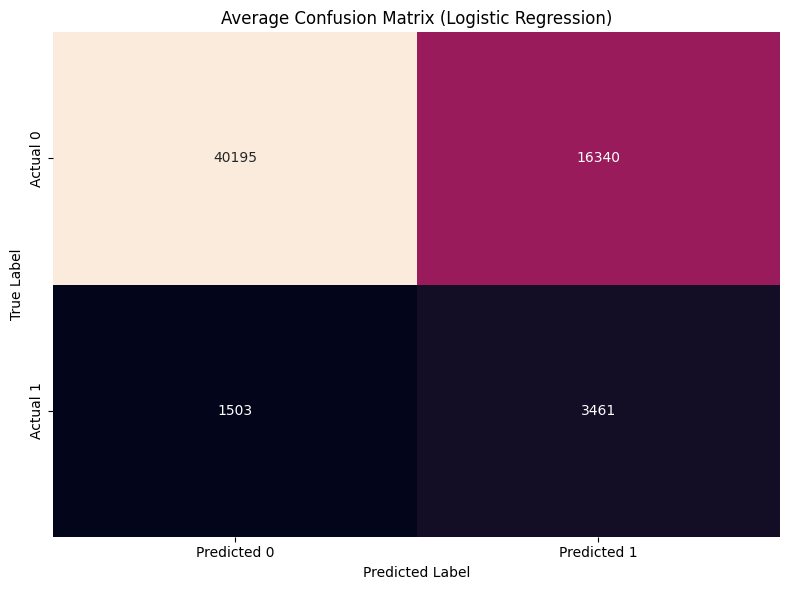

In [26]:
mean_cm = np.mean(conf_matrices, axis=0)

plt.figure(figsize=(8, 6))
sns.heatmap(mean_cm.astype(int), annot=True, fmt='d', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Average Confusion Matrix (Logistic Regression)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

#### 1.3 Feature Importance

In [15]:
coef_mat = np.vstack(coef_list)  # (n_folds, n_features)
coef_mean = coef_mat.mean(axis=0)
coef_abs_mean = np.abs(coef_mat).mean(axis=0)

feature_importance_logreg = (pd.DataFrame({"feature": X.columns,
                                        "coef_abs_mean": coef_abs_mean})
                                .sort_values("coef_abs_mean", ascending=False)
                                .reset_index(drop=True))

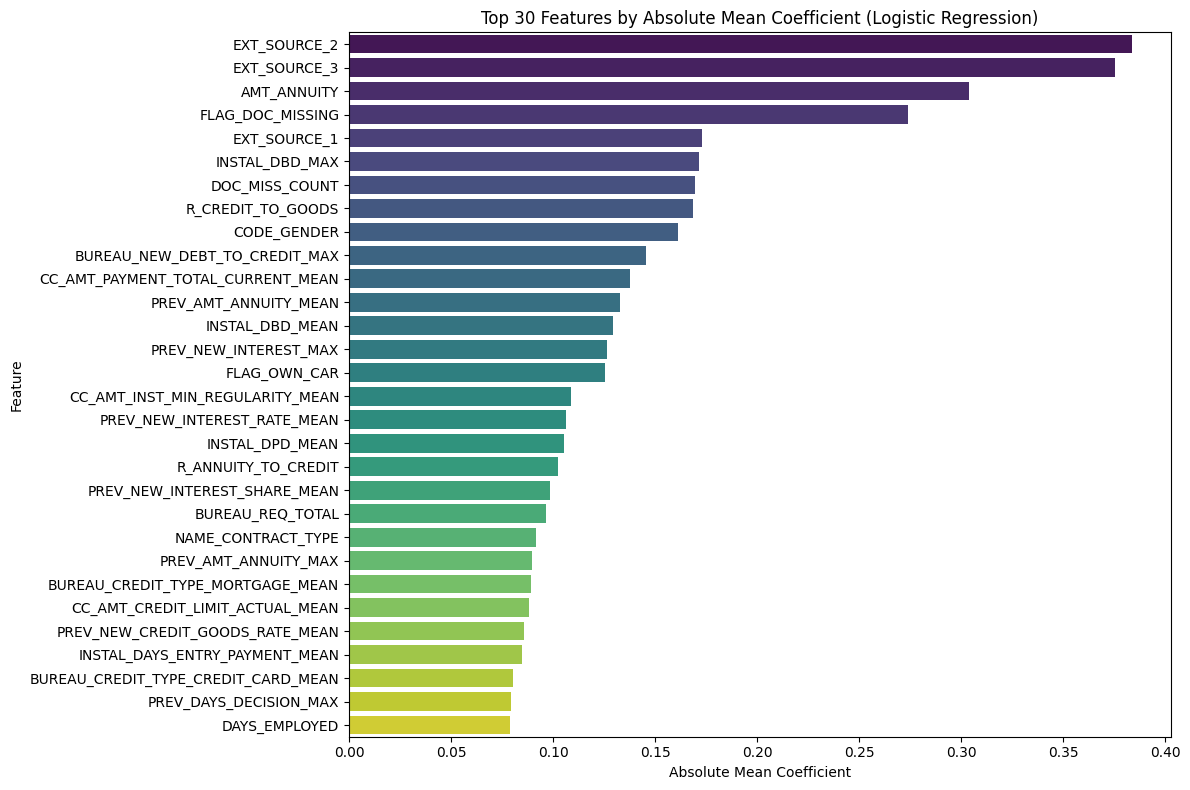

In [22]:
plt.figure(figsize=(12, 8))
sns.barplot(x='coef_abs_mean', y='feature', hue='feature', data=feature_importance_logreg.head(30), palette='viridis', legend=False)
plt.title('Top 30 Features by Absolute Mean Coefficient (Logistic Regression)')
plt.xlabel('Absolute Mean Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### 2. XGBoost

In [27]:
app_all_fe = pd.read_csv(os.path.join(base_path, 'results/app_all_fe.csv'))

In [28]:
# Divide the final dataset back into train and test
df = app_all_fe.copy()

train_df = df[df["TARGET"].notnull()].copy()
test_df  = df[df["TARGET"].isnull()].copy()

print("Train shape:", train_df.shape, "Test shape:", test_df.shape)

Train shape: (307505, 387) Test shape: (48744, 387)


In [29]:
# Preparing X(train), y(train), X_test
y = train_df["TARGET"].astype(int)
test_ids = test_df["SK_ID_CURR"].values

drop_cols = ["TARGET", "SK_ID_CURR"]
X = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])

X_test  = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns])
X_test = X_test.reindex(columns=X.columns) # make sure columns align

#### 2.1 Feature Selection

In [ ]:
N_FOLDS=5
folds = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_preds = np.zeros(len(X))
feature_importance = pd.DataFrame({"feature": X.columns})

In [ ]:
for fold, (trn_idx, val_idx) in enumerate(folds.split(X, y), 1):

    X_tr, X_va = X.iloc[trn_idx], X.iloc[val_idx]
    y_tr, y_va = y.iloc[trn_idx], y.iloc[val_idx]

    params = {
    "objective": "binary:logistic",
    "tree_method": "hist",
    "eval_metric": "auc",
    "seed": 42,
    "verbosity": 0,

    # Class imbalance
    "scale_pos_weight": float((y_tr == 0).sum() / (y_tr == 1).sum()),

    # Learning
    "eta": 0.08,
    "max_depth": 3,
    "min_child_weight": 6,
    "gamma": 4.624686525419818,

    # Subsampling
    "subsample": 0.7664089979018018,
    "colsample_bytree": 0.7364381541053394,

    # Regularization
    "alpha": 5.825880573703409,
    "lambda": 2.9507906938728468,
  }

    dtrain = xgb.DMatrix(X_tr, label=y_tr, feature_names=list(X.columns))
    dvalid = xgb.DMatrix(X_va, label=y_va, feature_names=list(X.columns))

    # Train with early stopping
    evals_result = {}
    booster = xgb.train(params=params, dtrain=dtrain, num_boost_round=10000,
                    evals=[(dtrain, "train"), (dvalid, "valid")], early_stopping_rounds=200,
                    verbose_eval=False, evals_result=evals_result)

    print("best_iteration:", booster.best_iteration)
    print("best_score:", booster.best_score)

    # Validation preds / AUC
    val_preds = booster.predict(dvalid)
    oof_preds[val_idx] = val_preds
    val_auc = roc_auc_score(y_va, val_preds)

    # Train preds / AUC
    train_preds = booster.predict(dtrain)
    train_auc = roc_auc_score(y_tr, train_preds)

    # Feature importance (gain)
    gain_dict = booster.get_score(importance_type="gain")
    fold_imp = pd.DataFrame({"feature": X.columns,
                            "importance": [gain_dict.get(f, 0.0) for f in X.columns],
                            "fold": fold})

    feature_importance = pd.concat([feature_importance, fold_imp], axis=0, ignore_index=True)

    print(f"Fold {fold} |" f"Train AUC: {train_auc:.5f} |" f"Valid AUC: {val_auc:.5f}")
    print("-"*20)

print("Full OOF AUC:", roc_auc_score(y, oof_preds))

best_iteration: 1338
best_score: 0.7851523723229723
Fold 1 |Train AUC: 0.85967 |Valid AUC: 0.78458
--------------------
best_iteration: 1132
best_score: 0.7961567750822903
Fold 2 |Train AUC: 0.85191 |Valid AUC: 0.79562
--------------------
best_iteration: 1050
best_score: 0.7865993235370103
Fold 3 |Train AUC: 0.85053 |Valid AUC: 0.78618
--------------------
best_iteration: 1067
best_score: 0.7909958662811749
Fold 4 |Train AUC: 0.85067 |Valid AUC: 0.79073
--------------------
best_iteration: 1023
best_score: 0.7871755981555336
Fold 5 |Train AUC: 0.84912 |Valid AUC: 0.78659
--------------------
Full OOF AUC: 0.7887202387135874


In [ ]:
fi = (feature_importance.groupby("feature")["importance"].mean()
                                                        .sort_values(ascending=False)
                                                        .reset_index())
fi.head(20)

,feature,importance
0,EXT_SOURCE_2,730.789172
1,EXT_SOURCE_3,688.165125
2,NAME_EDUCATION_TYPE_HIGHER_EDUCATION,640.035480
3,CC_NEW_CRED_UTIL_MAX,375.367969
4,INSTAL_DPD_MEAN,360.655762
5,CODE_GENDER,335.061053
6,INSTAL_DPD_MAX,318.376648
7,NAME_INCOME_TYPE_WORKING,316.586340
8,R_CREDIT_TO_GOODS,296.649249
9,DAYS_EMPLOYED,277.941364


In [ ]:
# Remove 30% of least useful features from the final dataset
drop_frac = 0.30
n_drop = int(len(fi) * drop_frac)

to_drop = fi.tail(n_drop)["feature"].tolist()
pd.Series(to_drop).to_csv(os.path.join(base_path, 'results/features_to_drop_xgb.csv'), index=True)

In [31]:
to_drop = pd.read_csv(os.path.join(base_path, 'results/features_to_drop_xgb.csv'))["0"].tolist()
app_all_fe_xgb = app_all_fe.drop(columns=to_drop)

In [ ]:
app_all_fe_xgb.shape[1] # Number of features left

272

#### 2.2 Hyperparameter Tuning (Bayesian)

In [32]:
# Loading reduced dataset (after feature selection)
df = app_all_fe_xgb.copy()

train_df = df[df["TARGET"].notnull()].copy()
test_df  = df[df["TARGET"].isnull()].copy()

print("Train shape:", train_df.shape, "Test shape:", test_df.shape)

Train shape: (307505, 272) Test shape: (48744, 272)


In [33]:
# Preparing X(train), y(train), X_test
y = train_df["TARGET"].astype(int)
test_ids = test_df["SK_ID_CURR"].values

drop_cols = ["TARGET", "SK_ID_CURR"]
X = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])

X_test  = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns])
X_test = X_test.reindex(columns=X.columns) # make sure columns align

In [ ]:
# Dividing X(train), y(train) into X_train, X_valid, y_train, y_valid
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
def objective(trial):
    """
    Optuna objective for tuning an XGBoost binary classifier (native xgb.train).

    Trains with early stopping on a fixed train/valid split, maximizes valid AUC,
    and stores train AUC + best_iteration as trial diagnostics.

    Returns:
        float: Validation ROC-AUC.
    """
    params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "tree_method": "hist",
        "seed": 42,

        # Class imbalance
        "scale_pos_weight": float((y_train == 0).sum() / (y_train == 1).sum()),

        # Learning
        "eta": trial.suggest_float("learning_rate", 0.01, 0.08),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),

        # Subsampling
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),

        # Regularization
        "alpha": trial.suggest_float("reg_alpha", 0.0, 10.0),
        "lambda": trial.suggest_float("reg_lambda", 0.0, 10.0),
    }

    # DMatrix
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dvalid = xgb.DMatrix(X_valid, label=y_valid)

    # Tain with early stopping
    evals = [(dtrain, "train"), (dvalid, "valid")]
    booster = xgb.train(params=params, dtrain=dtrain, num_boost_round=1000,
                        evals=evals, early_stopping_rounds=100, verbose_eval=False)

    # Predictions using best iteration
    val_preds = booster.predict(dvalid)
    train_preds = booster.predict(dtrain)

    # Metrics
    val_auc = roc_auc_score(y_valid, val_preds)
    train_auc = roc_auc_score(y_train, train_preds)

    # Store diagnostics
    trial.set_user_attr("train_auc", float(train_auc))
    trial.set_user_attr("best_iteration", int(booster.best_iteration))

    print(f"[Trial {trial.number}] " f"train_auc={train_auc:.6f} | val_auc={val_auc:.6f}")
    print("-" * 20)

    return val_auc

In [ ]:
# Hyperparameter tuning with Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

[I 2026-02-05 01:19:25,382] A new study created in memory with name: no-name-ec23ae2f-1313-404f-a118-9d2b3f5c4247
[I 2026-02-05 01:20:24,801] Trial 0 finished with value: 0.7892052062185403 and parameters: {'learning_rate': 0.07878949885400169, 'max_depth': 4, 'min_child_weight': 6, 'gamma': 0.1934170721435452, 'subsample': 0.9981792118709089, 'colsample_bytree': 0.8792698135377484, 'reg_alpha': 9.473460935463239, 'reg_lambda': 5.278727244862349}. Best is trial 0 with value: 0.7892052062185403.


[Trial 0] train_auc=0.856800 | val_auc=0.789205
--------------------


[I 2026-02-05 01:21:54,835] Trial 1 finished with value: 0.7904703538181733 and parameters: {'learning_rate': 0.03038585194559241, 'max_depth': 4, 'min_child_weight': 3, 'gamma': 1.7182731457125278, 'subsample': 0.834128191103696, 'colsample_bytree': 0.8600531796936911, 'reg_alpha': 1.3874070201058442, 'reg_lambda': 1.0064614598991894}. Best is trial 1 with value: 0.7904703538181733.


[Trial 1] train_auc=0.837469 | val_auc=0.790470
--------------------


[I 2026-02-05 01:24:12,975] Trial 2 finished with value: 0.7864906617441377 and parameters: {'learning_rate': 0.021974250874428752, 'max_depth': 8, 'min_child_weight': 8, 'gamma': 1.65025658925873, 'subsample': 0.8017040656429896, 'colsample_bytree': 0.8458574234009222, 'reg_alpha': 1.7231570467341695, 'reg_lambda': 4.01378497628478}. Best is trial 1 with value: 0.7904703538181733.


...

[Trial 17] train_auc=0.861947 | val_auc=0.791202
--------------------


[I 2026-02-05 01:48:21,704] Trial 18 finished with value: 0.7805591614059133 and parameters: {'learning_rate': 0.013584777711861305, 'max_depth': 3, 'min_child_weight': 7, 'gamma': 0.3838331007249653, 'subsample': 0.875171755090353, 'colsample_bytree': 0.832285680887148, 'reg_alpha': 5.158178057740776, 'reg_lambda': 8.659554086272596}. Best is trial 4 with value: 0.7916954606256815.


[Trial 18] train_auc=0.791826 | val_auc=0.780559
--------------------


[I 2026-02-05 01:49:36,035] Trial 19 finished with value: 0.7902568153956141 and parameters: {'learning_rate': 0.05045332400548506, 'max_depth': 6, 'min_child_weight': 9, 'gamma': 1.269227117028859, 'subsample': 0.826727307623579, 'colsample_bytree': 0.9037203834273744, 'reg_alpha': 5.846493723360097, 'reg_lambda': 6.709219158465263}. Best is trial 4 with value: 0.7916954606256815.


[Trial 19] train_auc=0.914057 | val_auc=0.790257
--------------------


In [ ]:
best_val_auc = study.best_value
best_trial = study.best_trial
best_params = study.best_params

print("Best VAL AUC:", best_val_auc)
print("Best TRAIN AUC:", best_trial.user_attrs["train_auc"])
print("Best params:", best_params)

Best VAL AUC: 0.7916954606256815
Best TRAIN AUC: 0.8460353929145449
Best params: {'learning_rate': 0.0397874834430522, 'max_depth': 4, 'min_child_weight': 10, 'gamma': 0.7663153536554673, 'subsample': 0.7820351884156318, 'colsample_bytree': 0.8495188195607734, 'reg_alpha': 9.724716972840113, 'reg_lambda': 9.98217000185283}


In [ ]:
# Save best parameters
with open(os.path.join(base_path, "results/best_params_xgb.json"), "w") as f:
    json.dump(best_params, f, indent=4)

#### 2.3 Tuned Model

In [34]:
# Load best paramters
with open(os.path.join(base_path, "results/best_params_xgb.json"), "r") as f:
    best_params = json.load(f)

In [35]:
THRESHOLD = 0.5 # classification cutoff
N_SPLITS = 5 # folds

folds = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

oof = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

train_aucs, val_aucs = [], []
pr_aucs = []
precisions, recalls = [], []
conf_matrices = []

fi = pd.DataFrame({"feature": X.columns})

In [36]:
for fold, (trn_idx, val_idx) in enumerate(folds.split(X, y), 1):
    X_tr, X_va = X.iloc[trn_idx], X.iloc[val_idx]
    y_tr, y_va = y.iloc[trn_idx], y.iloc[val_idx]

    dtrain = xgb.DMatrix(X_tr, label=y_tr)
    dvalid = xgb.DMatrix(X_va, label=y_va)
    dtest  = xgb.DMatrix(X_test)

    params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "tree_method": "hist",
        "seed": 42,
        "verbosity": 0,

        # Class imbalance
        "scale_pos_weight": float((y_tr == 0).sum() / (y_tr == 1).sum()),

        # Learning
        "eta": best_params["learning_rate"],
        "max_depth": best_params["max_depth"],
        "min_child_weight": best_params["min_child_weight"],
        "gamma": best_params["gamma"],

        # Subsampling
        "subsample": best_params["subsample"],
        "colsample_bytree": best_params["colsample_bytree"],

        # Regularization
        "alpha": best_params["reg_alpha"],
        "lambda": best_params["reg_lambda"]

    }

    # Train with early stopping
    booster = xgb.train(params=params, dtrain=dtrain, num_boost_round=10000,
                        evals=[(dtrain, "train"), (dvalid, "valid")],
                        callbacks=[EarlyStopping(rounds=200, save_best=True)],
                        verbose_eval=False)

    # Predictions using best iteration
    val_preds = booster.predict(dvalid)
    train_preds = booster.predict(dtrain)
    test_fold_preds = booster.predict(dtest)

    # Store OOF + test preds
    oof[val_idx] = val_preds
    test_preds += test_fold_preds / N_SPLITS

    # Metrics
    val_auc = roc_auc_score(y_va, val_preds)
    train_auc = roc_auc_score(y_tr, train_preds)

    pr_auc = average_precision_score(y_va, val_preds)

    val_labels = (val_preds >= THRESHOLD).astype(int)
    precision = precision_score(y_va, val_labels, zero_division=0)
    recall = recall_score(y_va, val_labels, zero_division=0)
    cm = confusion_matrix(y_va, val_labels)

    # Feature importance (gain)
    gain_dict = booster.get_score(importance_type="gain")
    fi[f"fold{fold}"] = [gain_dict.get(col, 0.0) for col in X.columns]

    # Store fold stats
    train_aucs.append(train_auc)
    val_aucs.append(val_auc)
    pr_aucs.append(pr_auc)
    precisions.append(precision)
    recalls.append(recall)
    conf_matrices.append(cm)

    print(f"Fold {fold} | " f"Train AUC: {train_auc:.5f} | " f"Valid AUC: {val_auc:.5f}")

Fold 1 | Train AUC: 0.86138 | Valid AUC: 0.78733
Fold 2 | Train AUC: 0.86307 | Valid AUC: 0.79610
Fold 3 | Train AUC: 0.86075 | Valid AUC: 0.78881
Fold 4 | Train AUC: 0.86787 | Valid AUC: 0.79375
Fold 5 | Train AUC: 0.85654 | Valid AUC: 0.78818


In [ ]:
# Save test predictions
submission = pd.DataFrame({"SK_ID_CURR": test_ids, "TARGET": test_preds})
submission.to_csv(os.path.join(base_path, "results/submission_xgb.csv"), index=False)

In [37]:
print(f"Mean Train AUC: {np.mean(train_aucs):.5f}")
print(f"Mean Valid AUC: {np.mean(val_aucs):.5f}")
print(f"Full OOF AUC:   {roc_auc_score(y, oof):.5f}")
print(f"Mean PR-AUC:    {np.mean(pr_aucs):.5f}")
print(f"Mean Precision: {np.mean(precisions):.5f}")
print(f"Mean Recall:    {np.mean(recalls):.5f}")

Mean Train AUC: 0.86192
Mean Valid AUC: 0.79083
Full OOF AUC:   0.79083
Mean PR-AUC:    0.28508
Mean Precision: 0.19803
Mean Recall:    0.67505


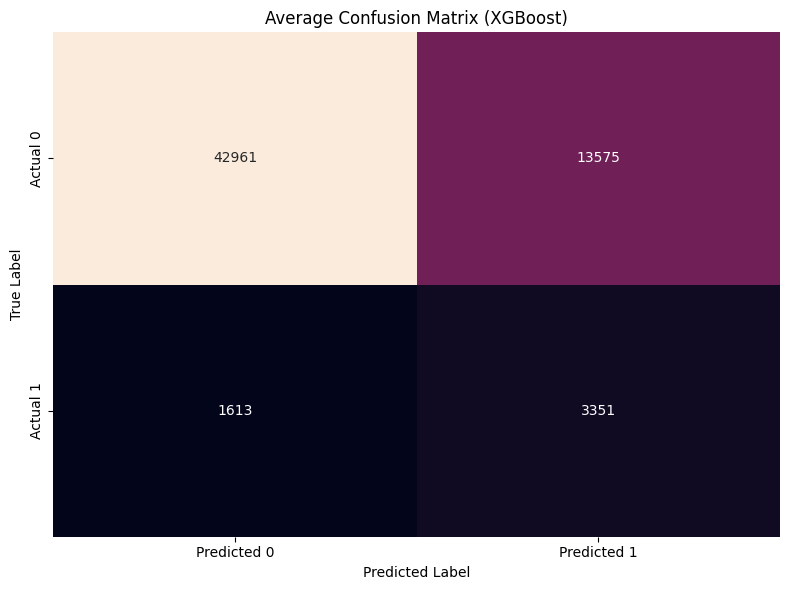

In [39]:
mean_cm = np.mean(conf_matrices, axis=0)

plt.figure(figsize=(8, 6))
sns.heatmap(mean_cm.astype(int), annot=True, fmt='d', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Average Confusion Matrix (XGBoost)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

#### 2.4 Feature Importance

In [43]:
fi["importance_gain_mean"] = fi.drop(columns=["feature"]).mean(axis=1)
fi = fi.sort_values("importance_gain_mean", ascending=False).reset_index(drop=True)

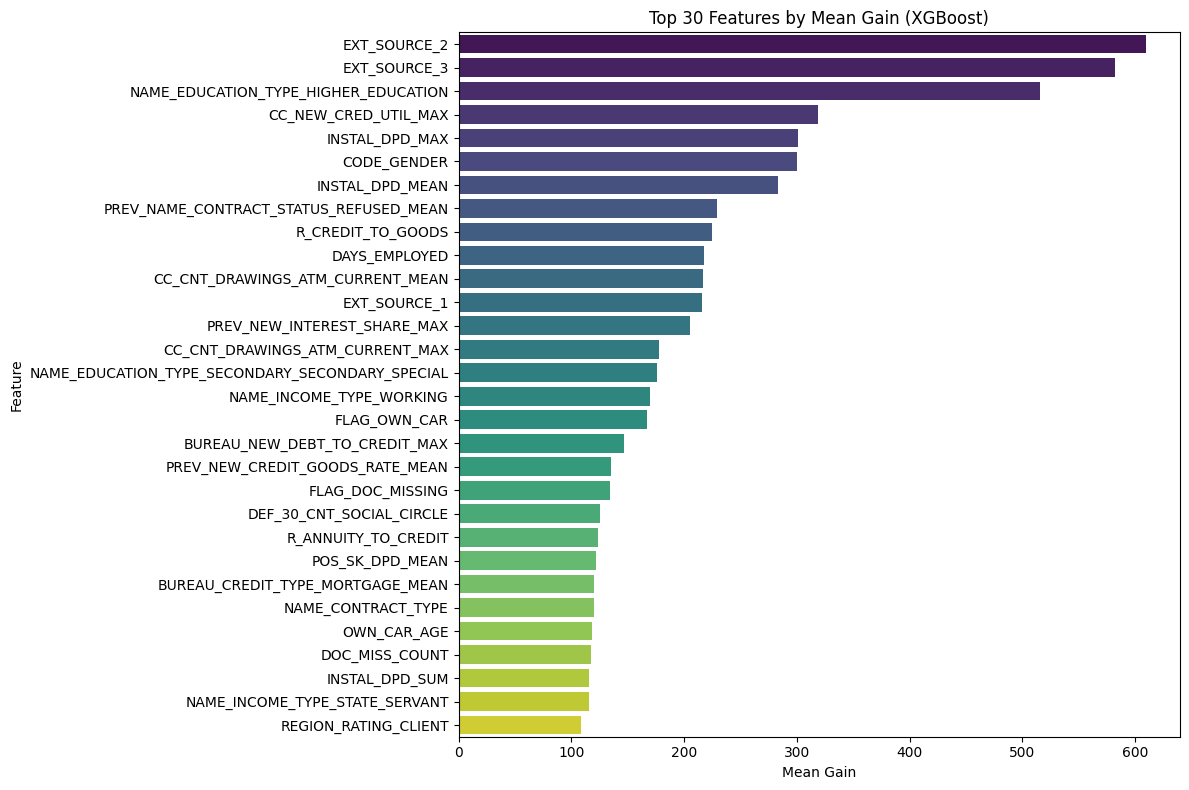

In [44]:
plt.figure(figsize=(12, 8))
sns.barplot(x='importance_gain_mean', y='feature', hue='feature', data=fi.head(30), palette='viridis', legend=False)
plt.title('Top 30 Features by Mean Gain (XGBoost)')
plt.xlabel('Mean Gain')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### 3. LightGBM

In [45]:
app_all_fe = pd.read_csv(os.path.join(base_path, 'results/app_all_fe.csv'))

In [46]:
# Divide the final dataset back into train and test
df = app_all_fe.copy()

train_df = df[df["TARGET"].notnull()].copy()
test_df  = df[df["TARGET"].isnull()].copy()

print("Train shape:", train_df.shape, "Test shape:", test_df.shape)

Train shape: (307505, 387) Test shape: (48744, 387)


In [47]:
# Preparing X(train), y(train), X_test
y = train_df["TARGET"].astype(int)
test_ids = test_df["SK_ID_CURR"].values

drop_cols = ["TARGET", "SK_ID_CURR"]
X = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])

X_test  = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns])
X_test = X_test.reindex(columns=X.columns) # make sure columns align

#### 3.1 Feature Selection

In [ ]:
N_FOLDS = 5
folds = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

feature_importance = pd.DataFrame()
oof_preds = np.zeros(len(X))

In [ ]:
params = {
    "objective": "binary",
    "metric": "auc",
    "boosting_type": "gbdt",
    "n_estimators": 10000,
    "verbosity": -1,
    "n_jobs": -1,
    "is_unbalance": True,

    # Learning
    "learning_rate": 0.029360636563064944,
    "num_leaves": 27,
    "max_depth": -1,
    "min_child_samples": 74,

    # Subsampling
    "subsample": 0.8904059852190885,
    "colsample_bytree": 0.8196420804443224,

    # Regularization
    "reg_alpha": 7.061471444104642,
    "reg_lambda": 9.049162727556453
  }

In [ ]:
for fold, (trn_idx, val_idx) in enumerate(folds.split(X, y), start=1):
    X_tr, X_va = X.iloc[trn_idx], X.iloc[val_idx]
    y_tr, y_va = y.iloc[trn_idx], y.iloc[val_idx]

    # Train model
    model = LGBMClassifier(**params)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], eval_metric="auc",
              callbacks=[early_stopping(200)])

    best_iter = model.best_iteration_

    # Validation predictions
    val_preds = model.predict_proba(X_va, num_iteration=best_iter)[:, 1]
    oof_preds[val_idx] = val_preds
    val_auc = roc_auc_score(y_va, val_preds)

    # Train predictions
    train_preds = model.predict_proba(X_tr, num_iteration=best_iter)[:, 1]
    train_auc = roc_auc_score(y_tr, train_preds)

    # Feature importance (gain)
    fold_imp = pd.DataFrame({"feature": X.columns,
                             "importance": model.booster_.feature_importance(importance_type="gain"),
                             "fold": fold})
    feature_importance = pd.concat([feature_importance, fold_imp], axis=0, ignore_index=True)

    print(f"Fold {fold} | " f"Train AUC: {train_auc:.5f} | " f"Valid AUC: {val_auc:.5f} ")
    print("-"*20)

# Final OOF performance
print("Full OOF AUC:", roc_auc_score(y, oof_preds))

Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1285]	valid_0's auc: 0.786223
Fold 1 | Train AUC: 0.88997 | Valid AUC: 0.78622 
--------------------
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1301]	valid_0's auc: 0.794895
Fold 2 | Train AUC: 0.88968 | Valid AUC: 0.79489 
--------------------
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1176]	valid_0's auc: 0.786165
Fold 3 | Train AUC: 0.88464 | Valid AUC: 0.78616 
--------------------
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[984]	valid_0's auc: 0.791365
Fold 4 | Train AUC: 0.87217 | Valid AUC: 0.79136 
--------------------
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[809]	valid_0's auc: 0.786879
Fold 5 | Train AUC: 0.86235 | Valid AUC: 0.78688 
--------------------
Full OO

In [ ]:
fi = (feature_importance.groupby("feature")["importance"].mean()
                                                        .sort_values(ascending=False)
                                                        .reset_index()
                                                        )

fi.head(20)

,feature,importance
0,EXT_SOURCE_3,447691.172716
1,EXT_SOURCE_2,442417.805980
2,EXT_SOURCE_1,176376.111412
3,R_ANNUITY_TO_CREDIT,111184.511263
4,PREV_NEW_INTEREST_SHARE_MAX,78559.568888
5,DAYS_EMPLOYED,76862.887192
6,R_CREDIT_TO_GOODS,70475.230252
7,DAYS_BIRTH,68455.595713
8,BUREAU_NEW_DEBT_TO_CREDIT_MAX,67977.168004
9,INSTAL_DPD_MEAN,50945.482721


In [ ]:
# Remove 30% of least useful features from the final dataset
drop_frac = 0.30
n_drop = int(len(fi) * drop_frac)

to_drop = fi.tail(n_drop)["feature"].tolist()
pd.Series(to_drop).to_csv(os.path.join(base_path, 'results/features_to_drop_lgbm.csv'), index=True)

In [48]:
to_drop = pd.read_csv(os.path.join(base_path, 'results/features_to_drop_lgbm.csv'))["0"].tolist()
app_all_fe_lgbm = app_all_fe.drop(columns=to_drop)

In [49]:
app_all_fe_lgbm.shape[1] # Number of features left

272

#### 3.2 Hyperparameter Tuning (Bayesian Optimization)

In [ ]:
# Loading reduced dataset (after feature selection)
df = app_all_fe_lgbm.copy()

train_df = df[df["TARGET"].notnull()].copy()
test_df  = df[df["TARGET"].isnull()].copy()

print("Train shape:", train_df.shape, "Test shape:", test_df.shape)

Train shape: (307505, 272) Test shape: (48744, 272)


In [ ]:
# Preparing X(train), y(train), X_test
y = train_df["TARGET"].astype(int)
test_ids = test_df["SK_ID_CURR"].values

drop_cols = ["TARGET", "SK_ID_CURR"]
X = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])

X_test  = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns])
X_test = X_test.reindex(columns=X.columns) # make sure columns align

In [ ]:
# Dividing X(train), y(train) into X_train, X_valid, y_train, y_valid
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
def objective(trial):
    """
    Optuna objective function for tuning an LightGBM binary classifier.

    Trains an LGBMClassifier with early stopping on a fixed
    train/validation split, optimizes validation AUC, and logs
    train AUC for overfitting diagnostics.

    Returns:
        float: Validation ROC-AUC score.
    """

    params = {
        "objective": "binary",
        "metric": "auc",
        "boosting_type": "gbdt",
        "n_estimators": 10_000,
        "verbosity": -1,
        "n_jobs": -1,
        "is_unbalance": True,

        # Learning
        "learning_rate": trial.suggest_float("lr", 0.01, 0.05),
        "num_leaves": trial.suggest_int("num_leaves", 20, 64),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 100),

        # Subsampling
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),

        # Regularization
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 10.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 10.0),
    }

    # Model training
    model = LGBMClassifier(**params)
    model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], eval_metric="auc",
              callbacks=[early_stopping(200)])

    # # Validation AUC
    val_preds = model.predict_proba(X_valid, num_iteration=model.best_iteration_)[:, 1]
    val_auc = roc_auc_score(y_valid, val_preds)

    # Train AUC
    train_preds = model.predict_proba(X_train, num_iteration=model.best_iteration_)[:, 1]
    train_auc = roc_auc_score(y_train, train_preds)

    # Save diagnostics into the trial
    trial.set_user_attr("train_auc", train_auc)
    trial.set_user_attr("best_iteration", model.best_iteration_)

    print(f"Trial {trial.number} |" f"train_auc={train_auc:.6f} | val_auc={val_auc:.6f} ")
    print("-" * 20)

    return val_auc

In [ ]:
# Hyperparameter tuning with Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

[I 2026-02-05 02:11:06,889] A new study created in memory with name: no-name-f5bb5ac9-17b7-47de-8952-97ce1f426ea4


Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[620]	valid_0's auc: 0.789891


[I 2026-02-05 02:12:42,668] Trial 0 finished with value: 0.7898913627884222 and parameters: {'lr': 0.031240358560641147, 'num_leaves': 51, 'min_child_samples': 62, 'subsample': 0.9390652455517234, 'colsample_bytree': 0.8905813410334414, 'reg_lambda': 3.470295871500222, 'reg_alpha': 4.879703958297687}. Best is trial 0 with value: 0.7898913627884222.


Trial 0 |train_auc=0.898006 | val_auc=0.789891 
--------------------
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[432]	valid_0's auc: 0.79018


[I 2026-02-05 02:14:00,363] Trial 1 finished with value: 0.7901796158791461 and parameters: {'lr': 0.04062888732627908, 'num_leaves': 64, 'min_child_samples': 58, 'subsample': 0.9638647232680277, 'colsample_bytree': 0.8230490059294824, 'reg_lambda': 4.144053743137927, 'reg_alpha': 2.352615193008576}. Best is trial 1 with value: 0.7901796158791461.


...

Trial 17 |train_auc=0.884583 | val_auc=0.789694 
--------------------
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1537]	valid_0's auc: 0.79153


[I 2026-02-05 02:56:39,413] Trial 18 finished with value: 0.7915301763540482 and parameters: {'lr': 0.015829569448290608, 'num_leaves': 42, 'min_child_samples': 20, 'subsample': 0.8202480933729929, 'colsample_bytree': 0.7008171121390314, 'reg_lambda': 2.0228688228870597, 'reg_alpha': 7.724097597858443}. Best is trial 14 with value: 0.7920003702156784.


Trial 18 |train_auc=0.896056 | val_auc=0.791530 
--------------------
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1195]	valid_0's auc: 0.791307


[I 2026-02-05 02:58:26,481] Trial 19 finished with value: 0.7913065471317476 and parameters: {'lr': 0.02403732739020665, 'num_leaves': 26, 'min_child_samples': 50, 'subsample': 0.8662424418510435, 'colsample_bytree': 0.7482302496001263, 'reg_lambda': 4.855863793898785, 'reg_alpha': 3.3268931264404644}. Best is trial 14 with value: 0.7920003702156784.


Trial 19 |train_auc=0.871306 | val_auc=0.791307 
--------------------


In [ ]:
# Parameters with best AUC performance
best = study.best_trial
best_params = study.best_params

print("Best VAL AUC:", best.value)
print("Best TRAIN AUC:", best.user_attrs["train_auc"])
print("Best params:", best_params)

Best VAL AUC: 0.7920003702156784
Best TRAIN AUC: 0.8798620568081564
Best params: {'lr': 0.018145564905733158, 'num_leaves': 26, 'min_child_samples': 20, 'subsample': 0.8536373260890827, 'colsample_bytree': 0.7049884606041515, 'reg_lambda': 5.914401612200552, 'reg_alpha': 8.233433623977213}


In [ ]:
# Save best parameters
with open(os.path.join(base_path, "results/best_params_lgbm.json"), "w") as f:
    json.dump(best_params, f, indent=4)

#### 3.3 Tuned Model

In [50]:
# Load best paramters
with open(os.path.join(base_path, "results/best_params_lgbm.json"), "r") as f:
    best_params = json.load(f)

In [51]:
params = {
      "objective": "binary",
      "metric": "auc",
      "boosting_type": "gbdt",
      "n_estimators": 10000,
      "verbosity": -1,
      "n_jobs": -1,
      "is_unbalance": True,

      # Learning
      "learning_rate": best_params["lr"],
      "num_leaves": best_params["num_leaves"],
      "min_child_samples": best_params["min_child_samples"],

      # Subsampling
      "subsample": best_params["subsample"],
      "colsample_bytree": best_params["colsample_bytree"],

      # Regularization
      "reg_alpha": best_params["reg_alpha"],
      "reg_lambda": best_params["reg_lambda"]
    }

In [52]:
THRESHOLD = 0.5 # classification cutoff
N_SPLITS = 5 # folds

folds = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

oof = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

train_aucs, val_aucs = [], []
pr_aucs = []
precisions, recalls = [], []
conf_matrices = []

fi = pd.DataFrame({"feature": X.columns})

In [53]:
for fold, (trn_idx, val_idx) in enumerate(folds.split(X, y), 1):

    X_tr, X_va = X.iloc[trn_idx], X.iloc[val_idx]
    y_tr, y_va = y.iloc[trn_idx], y.iloc[val_idx]

    # Training the model
    model = LGBMClassifier(**params)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], eval_metric="auc",
            callbacks=[early_stopping(200)])

    # Validation predictions
    val_preds = model.predict_proba(X_va, num_iteration=model.best_iteration_)[:, 1]
    oof[val_idx] = val_preds
    val_auc = roc_auc_score(y_va, val_preds)

    # Train predictions
    train_preds = model.predict_proba(X_tr, num_iteration=model.best_iteration_)[:, 1]
    train_auc = roc_auc_score(y_tr, train_preds)

    # Test predictions (accumulate)
    test_preds += model.predict_proba(X_test, num_iteration=model.best_iteration_)[:, 1] / N_SPLITS

    # Additional metrics
    pr_auc = average_precision_score(y_va, val_preds)

    val_labels = (val_preds >= THRESHOLD).astype(int)
    precision = precision_score(y_va, val_labels, zero_division=0)
    recall = recall_score(y_va, val_labels, zero_division=0)

    cm = confusion_matrix(y_va, val_labels)

    # Feature importance (gain)
    booster = model.booster_
    fi[f"fold{fold}"] = booster.feature_importance(importance_type="gain")

    # Store metrics
    train_aucs.append(train_auc)
    val_aucs.append(val_auc)
    pr_aucs.append(pr_auc)
    precisions.append(precision)
    recalls.append(recall)
    conf_matrices.append(cm)

    print(f"Fold {fold} | " f"Train AUC = {train_auc:.5f} | "f"Valid AUC = {val_auc:.5f} ")

Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[2313]	valid_0's auc: 0.786155
Fold 1 | Train AUC = 0.89441 | Valid AUC = 0.78616 
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1469]	valid_0's auc: 0.795642
Fold 2 | Train AUC = 0.86417 | Valid AUC = 0.79564 
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1894]	valid_0's auc: 0.786479
Fold 3 | Train AUC = 0.88100 | Valid AUC = 0.78648 
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1620]	valid_0's auc: 0.79121
Fold 4 | Train AUC = 0.86995 | Valid AUC = 0.79121 
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1446]	valid_0's auc: 0.787214
Fold 5 | Train AUC = 0.86526 | Valid AUC = 0.78721 


In [ ]:
# Save test predictions
submission = pd.DataFrame({"SK_ID_CURR": test_ids, "TARGET": test_preds})
submission.to_csv(os.path.join(base_path, 'results/submission_lbgm.csv'), index=False)

In [54]:
print(f"Mean Train AUC: {np.mean(train_aucs):.5f}")
print(f"Mean Valid AUC: {np.mean(val_aucs):.5f}")
print(f"Full OOF AUC:   {roc_auc_score(y, oof):.5f}")
print(f"Mean PR-AUC:    {np.mean(pr_aucs):.5f}")
print(f"Mean Precision: {np.mean(precisions):.5f}")
print(f"Mean Recall:    {np.mean(recalls):.5f}")

Mean Train AUC: 0.87496
Mean Valid AUC: 0.78934
Full OOF AUC:   0.78921
Mean PR-AUC:    0.28223
Mean Precision: 0.19644
Mean Recall:    0.67392


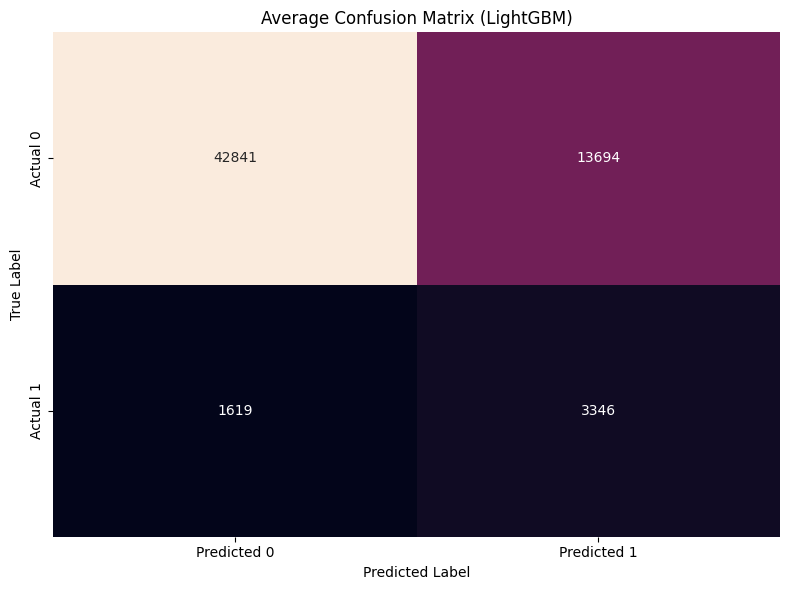

In [62]:
mean_cm = np.mean(conf_matrices, axis=0)

plt.figure(figsize=(8, 6))
sns.heatmap(mean_cm.astype(int), annot=True, fmt='d', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Average Confusion Matrix (LightGBM)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

#### 3.4 Feature Importance

In [60]:
fi["importance_gain_mean"] = fi.drop(columns=["feature"]).mean(axis=1)
fi = fi.sort_values("importance_gain_mean", ascending=False).reset_index(drop=True)

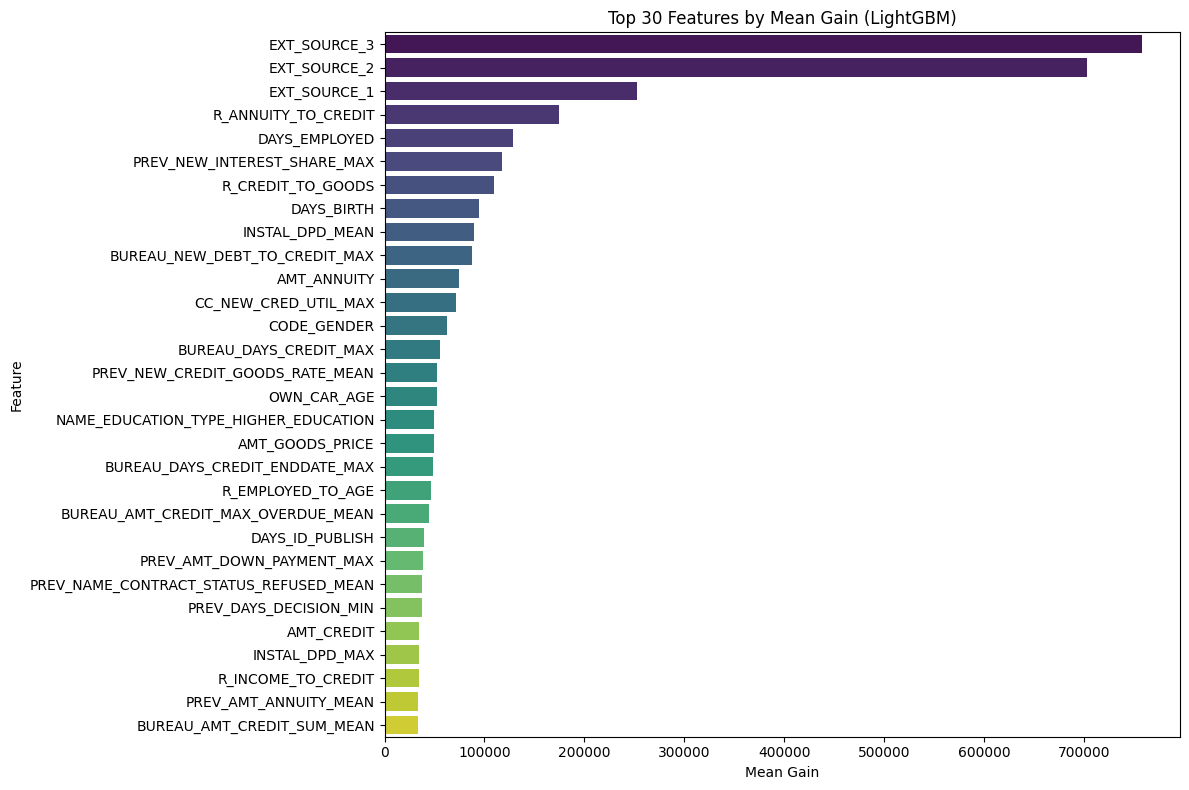

In [61]:
plt.figure(figsize=(12, 8))
sns.barplot(x='importance_gain_mean', y='feature', hue='feature', data=fi.head(30), palette='viridis', legend=False)
plt.title('Top 30 Features by Mean Gain (LightGBM)')
plt.xlabel('Mean Gain')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()